### ROUGH DRAFT NOTEBOOK FOR FORECASTING MODEL

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)

In [2]:
path = Path('projections')
projects = {}

for file in sorted(path.glob('*.csv'), key=lambda p: p.name):
    current_df = pd.read_csv(file)
    file_name = file.stem
    projects[file_name] = current_df

In [3]:
# Some formatting/ cleaning up stuff
for name, df in projects.items():
    df_cleaned = df.iloc[:, 1:].copy()

    if len(df_cleaned) > 0:
        df_cleaned.iat[-1, 0] = "Total"

        start_col_idx = 6
        if df_cleaned.shape[1] > start_col_idx:
            last_row = df_cleaned.iloc[[-1], start_col_idx:]
            cleaned_last_row = (
                last_row.astype("string")
                .apply(lambda s: s.str.split(r"\r\n|\n|\r", regex=True).str[0])
            )
            df_cleaned.iloc[-1, start_col_idx:] = cleaned_last_row.iloc[0].to_numpy()

    df_cleaned = df_cleaned.reset_index(drop=True)
    projects[name] = df_cleaned

In [4]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
master_timeline = timeline_dates.strftime('%b %Y').tolist()

for name, df in projects.items():
    static_columns = list(df.columns[:7])
    all_desired_columns = static_columns + master_timeline
    df_unified = df.reindex(columns=all_desired_columns, fill_value=0)
    projects[name] = df_unified

In [5]:
# Drop all categories and leave only totals
for name, df in projects.items():
    # --- START OF TRY-EXCEPT BLOCK ---
    try:
        # Find the row where the first column equals "Total"
        total_only = df[df.iloc[:, 0].astype(str).eq("Total")].copy()
        
        # Attempt to drop the specific text columns
        total_only = total_only.drop(columns=["Line Item", "Description"])
        
        # Save it back to the dictionary
        projects[name] = total_only.reset_index(drop=True)
        
    except Exception as e:
        print(f"⚠️ Failed to process totals for project: {name}")
        print(f"   Reason: {e}\n")
    # --- END OF TRY-EXCEPT BLOCK ---

In [6]:
# Add project code as first column
for name, df in projects.items():
    if df.empty:
        continue

    if "Project Code" in df.columns:
        df = df.drop(columns=["Project Code"])
    df.insert(0, "Project Code", name)

    projects[name] = df

In [7]:
# Squish all projects into a single dataframe
non_empty_projects = [df for df in projects.values() if not df.empty]
all_projects_df = pd.concat(non_empty_projects, ignore_index=True)

In [8]:
import os

# Remove "Actuals" columns (I don't think we need these?)
cols_to_drop = ["Actuals To Date", "Actuals + Projections"]
all_projects_df = all_projects_df.drop(columns=cols_to_drop, errors="ignore")

In [9]:
# Convert monthly spend to cumulative sum
timeline_cols = all_projects_df.columns[5:]

all_projects_df[timeline_cols] = (
    all_projects_df[timeline_cols]
    .astype(str)
    .replace({',': '', r'\(': '-', r'\)': ''}, regex=True)
    .astype(float)
)

all_projects_df[timeline_cols] = all_projects_df[timeline_cols].cumsum(axis=1)
all_projects_df.head(20)

,Project Code,Projected Budget,Projected Commitments,Estimate at Completion,Jan 2011,Feb 2011,Mar 2011,Apr 2011,May 2011,Jun 2011,Jul 2011,Aug 2011,Sep 2011,Oct 2011,Nov 2011,Dec 2011,Jan 2012,Feb 2012,Mar 2012,Apr 2012,May 2012,Jun 2012,Jul 2012,Aug 2012,Sep 2012,Oct 2012,Nov 2012,Dec 2012,Jan 2013,Feb 2013,Mar 2013,Apr 2013,May 2013,Jun 2013,Jul 2013,Aug 2013,Sep 2013,Oct 2013,Nov 2013,Dec 2013,Jan 2014,Feb 2014,Mar 2014,Apr 2014,May 2014,Jun 2014,Jul 2014,Aug 2014,Sep 2014,Oct 2014,Nov 2014,Dec 2014,Jan 2015,Feb 2015,Mar 2015,Apr 2015,May 2015,Jun 2015,Jul 2015,Aug 2015,Sep 2015,Oct 2015,Nov 2015,Dec 2015,Jan 2016,Feb 2016,Mar 2016,Apr 2016,May 2016,Jun 2016,Jul 2016,Aug 2016,Sep 2016,Oct 2016,Nov 2016,Dec 2016,Jan 2017,Feb 2017,Mar 2017,Apr 2017,May 2017,Jun 2017,Jul 2017,Aug 2017,Sep 2017,Oct 2017,Nov 2017,Dec 2017,Jan 2018,Feb 2018,Mar 2018,Apr 2018,May 2018,Jun 2018,Jul 2018,Aug 2018,Sep 2018,Oct 2018,Nov 2018,Dec 2018,Jan 2019,Feb 2019,Mar 2019,Apr 2019,May 2019,Jun 2019,Jul 2019,Aug 2019,Sep 2019,Oct 2019,Nov 2019,Dec 2019,Jan 2020,Feb 2020,Mar 2020,Apr 2020,May 2020,Jun 2020,Jul 2020,Aug 2020,Sep 2020,Oct 2020,Nov 2020,Dec 2020,Jan 2021,Feb 2021,Mar 2021,Apr 2021,May 2021,Jun 2021,Jul 2021,Aug 2021,Sep 2021,Oct 2021,Nov 2021,Dec 2021,Jan 2022,Feb 2022,Mar 2022,Apr 2022,May 2022,Jun 2022,Jul 2022,Aug 2022,Sep 2022,Oct 2022,Nov 2022,Dec 2022,Jan 2023,Feb 2023,Mar 2023,Apr 2023,May 2023,Jun 2023,Jul 2023,Aug 2023,Sep 2023,Oct 2023,Nov 2023,Dec 2023,Jan 2024,Feb 2024,Mar 2024,Apr 2024,May 2024,Jun 2024,Jul 2024,Aug 2024,Sep 2024,Oct 2024,Nov 2024,Dec 2024,Jan 2025,Feb 2025,Mar 2025,Apr 2025,May 2025,Jun 2025,Jul 2025,Aug 2025,Sep 2025,Oct 2025,Nov 2025,Dec 2025,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026,Oct 2026,Nov 2026,Dec 2026,Jan 2027,Feb 2027,Mar 2027,Apr 2027,May 2027,Jun 2027
0,4638,"42,860,000.00","42,530,755.44","42,860,782.00",0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1904.6,3278.52,3733.52,3733.52,3733.52,3733.52,3733.52,3733.52,3733.52,4228.52,5053.52,5713.52,6373.52,7033.52,7858.52,12760.77,12760.77,12760.77,12760.77,12760.77,12760.77,12760.77,12760.77,13000.77,14010.77,15888.27,20111.77,21801.27,31546.27,44240.42,47823.92,49517.42,56133.67,57235.85,86774.35,88189.6,103003.1,119132.1,120327.1,121692.1,122968.1,124825.6,127088.1,129876.1,133442.6,136778.6,138242.60,140706.60,142979.10,186921.62,203353.12,211196.62,216579.62,216579.62,596181.59,738910.61,739670.61,745883.68,803160.23,849543.33,1193059.37,1291745.72,1349269.68,1475958.67,1629468.81,1648803.46,1656094.77,1891200.66,1954611.89,2344429.25,2353431.75,2368902.75,2427325.75,2483925.72,2495831.37,2514442.81,2538544.83,2556386.33,2903964.75,3009625.63,3053797.97,3.076112e+06,3.091918e+06,3.117210e+06,3.165138e+06,3.183594e+06,3.216181e+06,3.260497e+06,3.313108e+06,3.346203e+06,3.385184e+06,3.440952e+06,3.702667e+06,3.720518e+06,4.330464e+06,4.486759e+06,4.552031e+06,4.686318e+06,4.794139e+06,4.830693e+06,7.114881e+06,8.629512e+06,9.833164e+06,1.120646e+07,1.451030e+07,1.456471e+07,1.667040e+07,1.854202e+07,2.031848e+07,2.283199e+07,2.736447e+07,2.738920e+07,2.920478e+07,3.347946e+07,3.515645e+07,3.418236e+07,3.390137e+07,3.627858e+07,3.638401e+07,3.702203e+07,3.816789e+07,3.875049e+07,3.920500e+07,3.943667e+07,3.950350e+07,3.954126e+07,3.957402e+07,3.960141e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,3.974134e+07,

In [10]:
# Remove project 5149 (no spending?)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5149"].reset_index(drop=True)

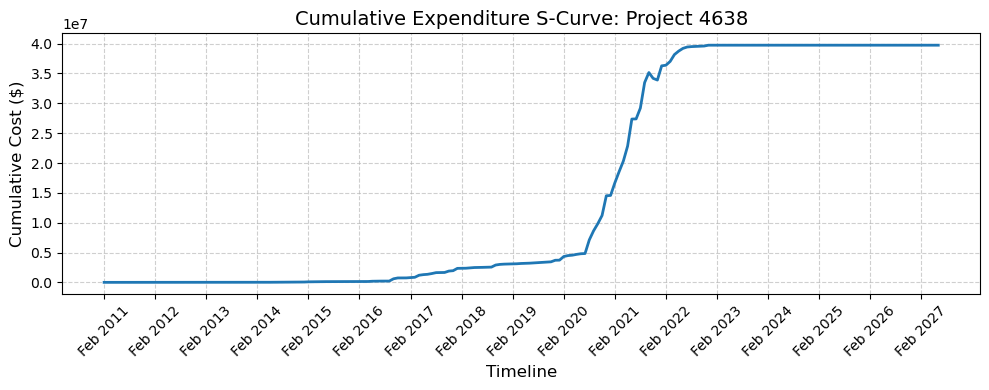

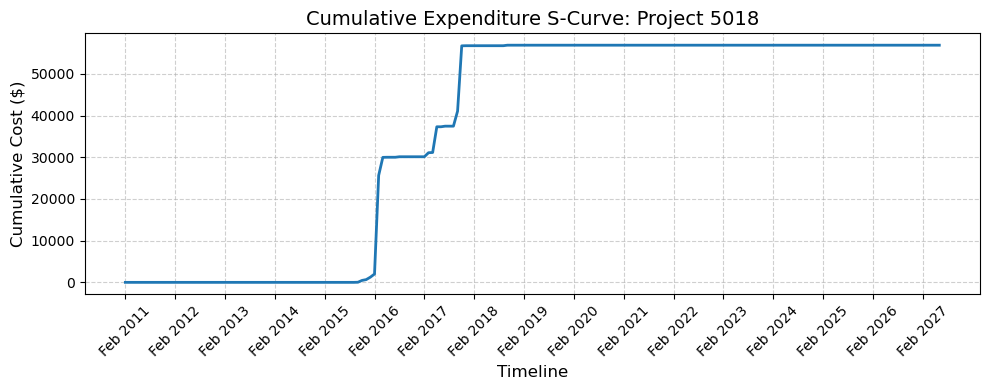

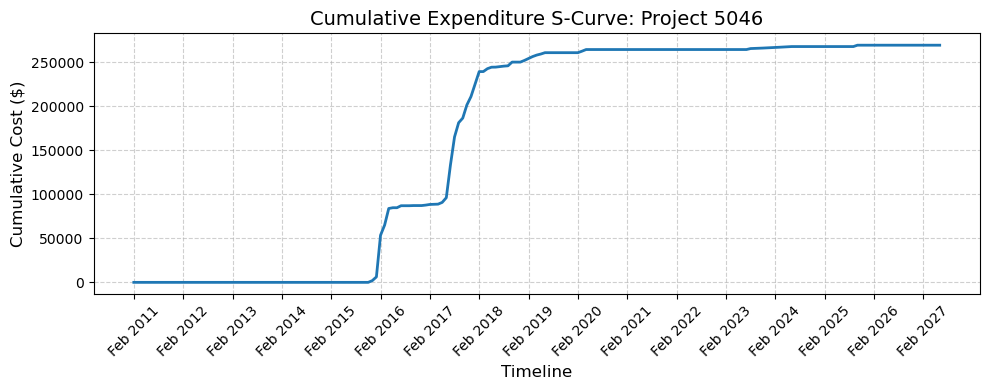

In [11]:
timeline_cols = all_projects_df.columns[5:]

# Plot first 3 S_curves using cumulative sums
for index, row in all_projects_df.head(3).iterrows():
    project_code = row['Project Code']
    cumulative_values = row[timeline_cols]
    plt.figure(figsize=(10, 4))
    plt.plot(timeline_cols, cumulative_values, linewidth=2, color='#1f77b4')
    plt.title(f"Cumulative Expenditure S-Curve: Project {project_code}", fontsize=14)
    plt.xlabel("Timeline", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.xticks(timeline_cols[::12], rotation=45) 
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

/var/folders/2j/cqg4vj2n1617_3jwzl8fvjnh0000gn/T/ipykernel_38184/1818820531.py:19: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (t - t0)))
/var/folders/2j/cqg4vj2n1617_3jwzl8fvjnh0000gn/T/ipykernel_38184/1818820531.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(logistic_curve, x_data, y_data, p0=initial_guess, maxfev=1000000)


,Project Code,Start_Date,Stop_Date,S_Curve_L,S_Curve_k,S_Curve_t0
0,4638,Apr 2012,Dec 2022,3.994062e+07,0.205584,120.997703
1,5018,Oct 2015,Oct 2018,5.704537e+04,0.151848,68.798635
2,5046,Dec 2015,Oct 2025,2.670126e+05,0.143228,74.591139
3,5058,Apr 2016,Oct 2021,4.566618e+08,0.202643,100.556762
4,5088,Jan 2017,Jul 2022,1.596853e+08,0.216121,118.146894
5,5105,May 2016,May 2027,1.223951e+06,0.017463,242.391428
6,5148,Jan 2017,Dec 2026,4.254116e+08,0.147077,168.434274
7,5171,Mar 2017,Jan 2026,5.064603e+08,0.112285,153.518840
8,5198,Jun 2019,Jan 2027,1.245737e+06,0.093073,118.097384
9,5199,May 2017,Mar 2025,5.813314e+06,0.068645,127.237127


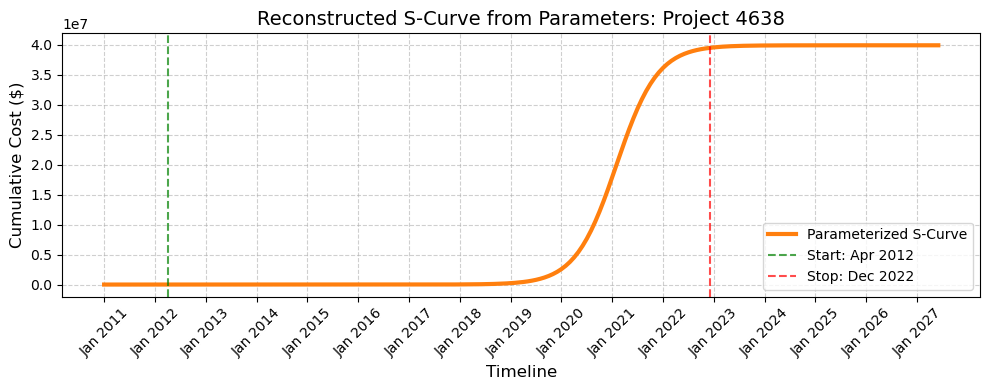

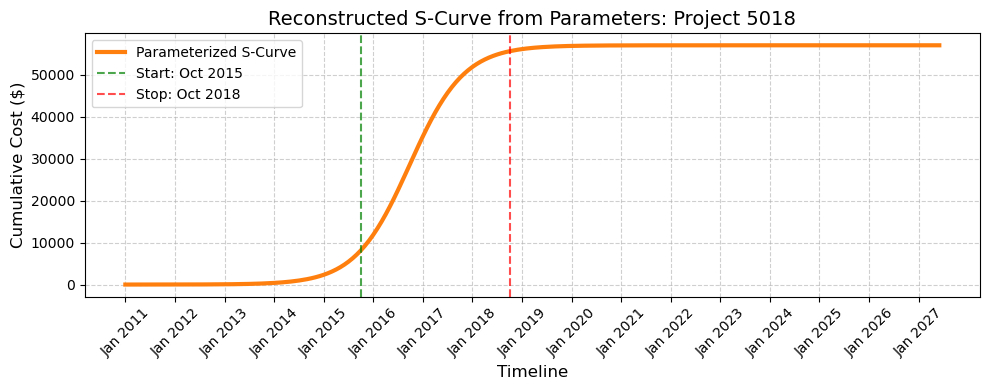

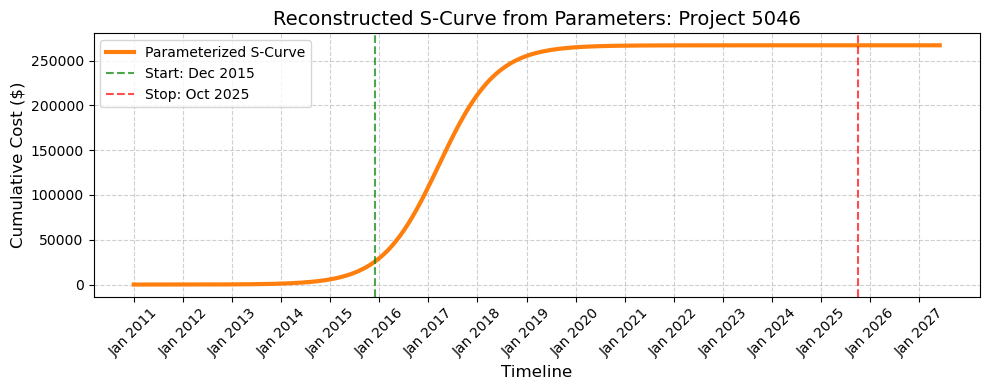

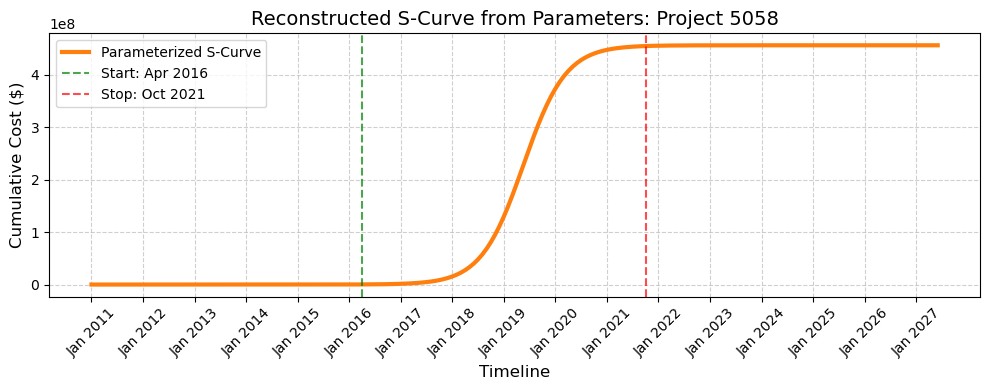

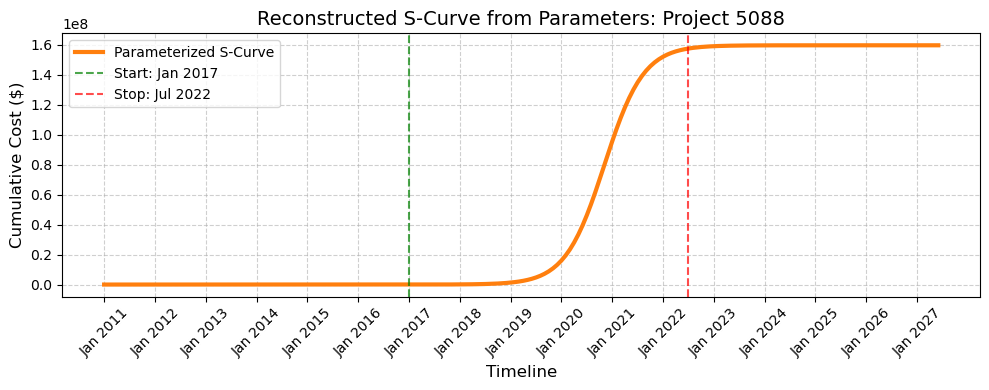

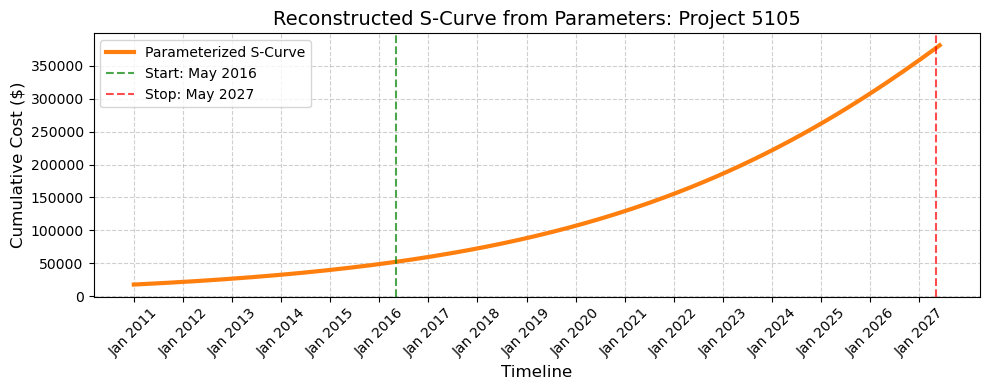

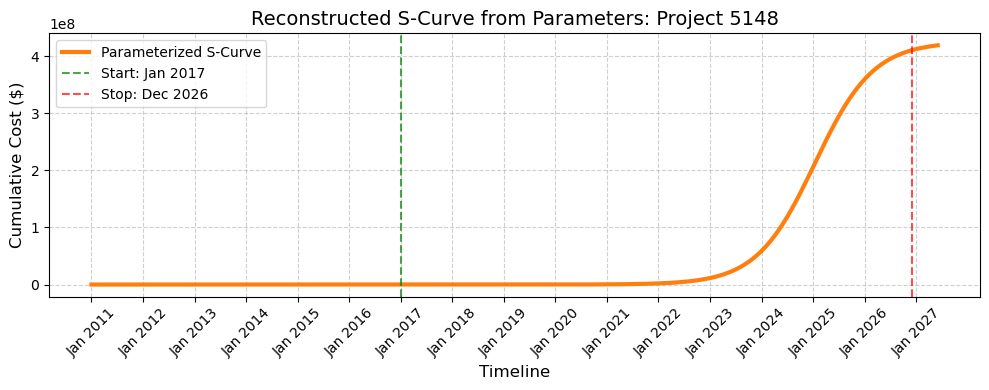

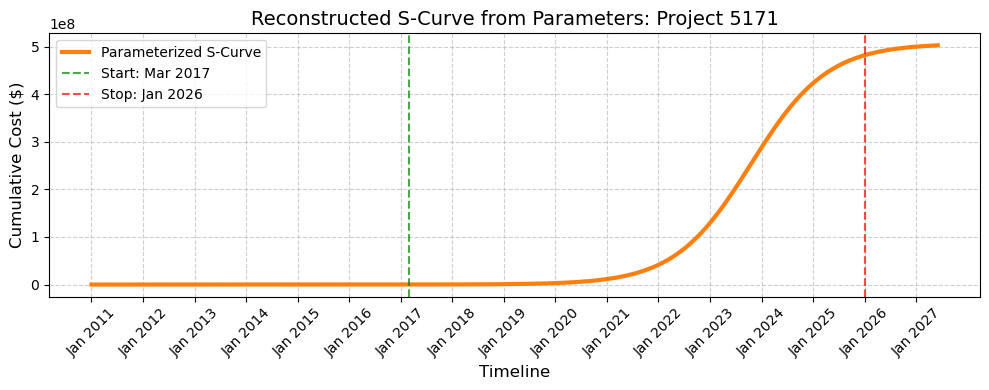

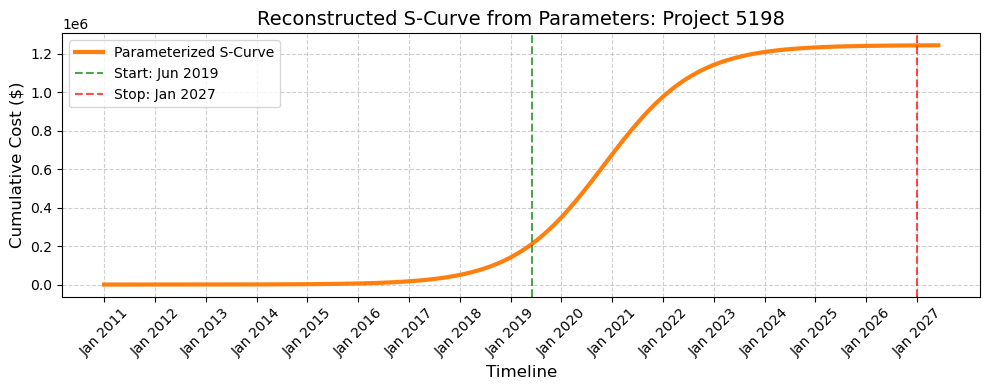

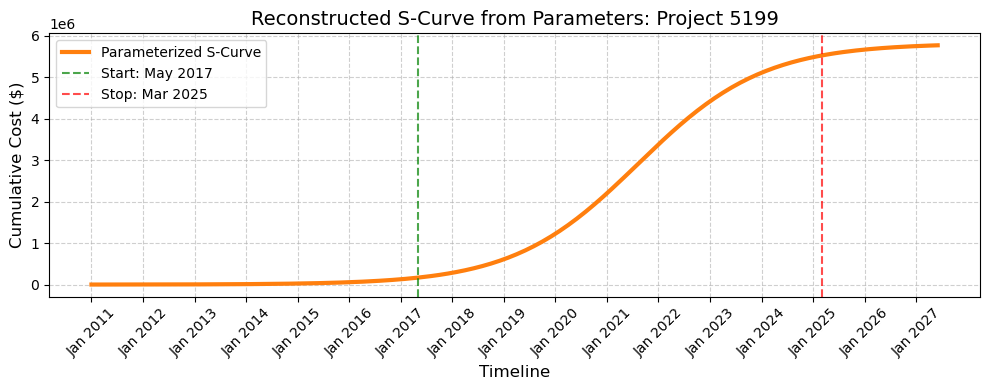

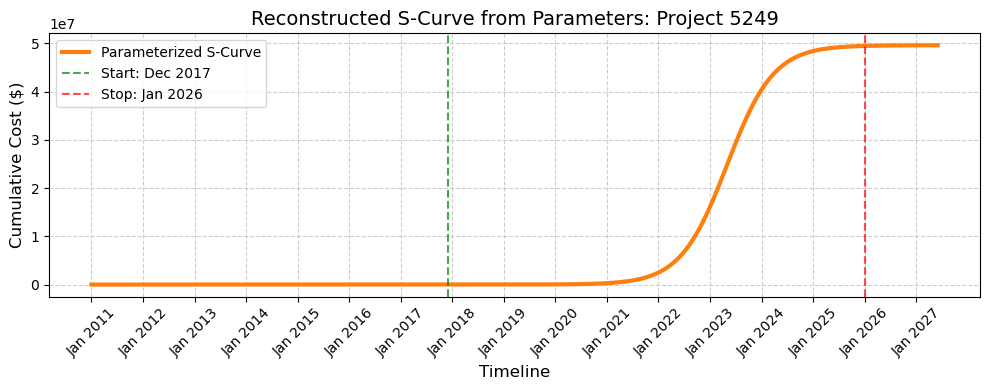

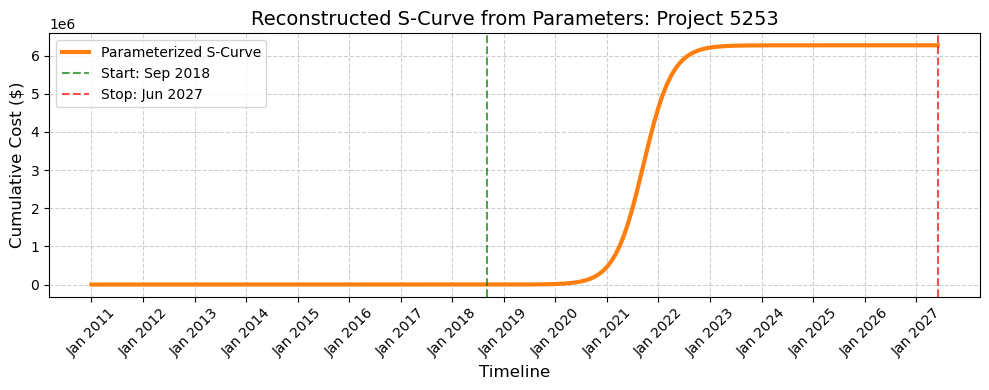

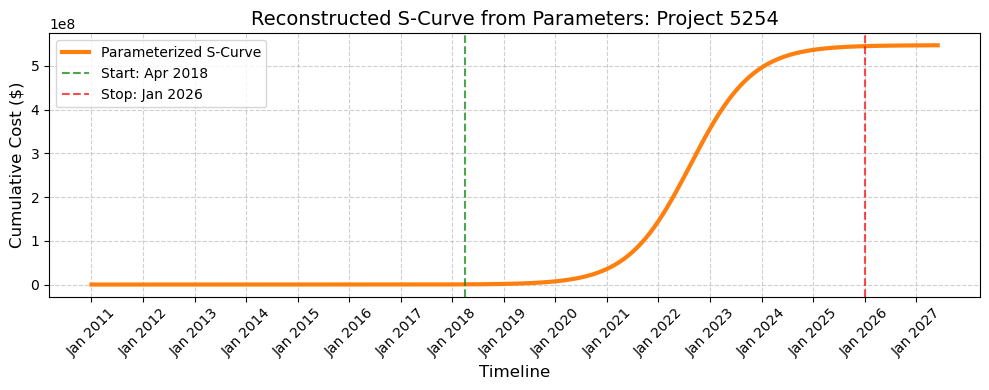

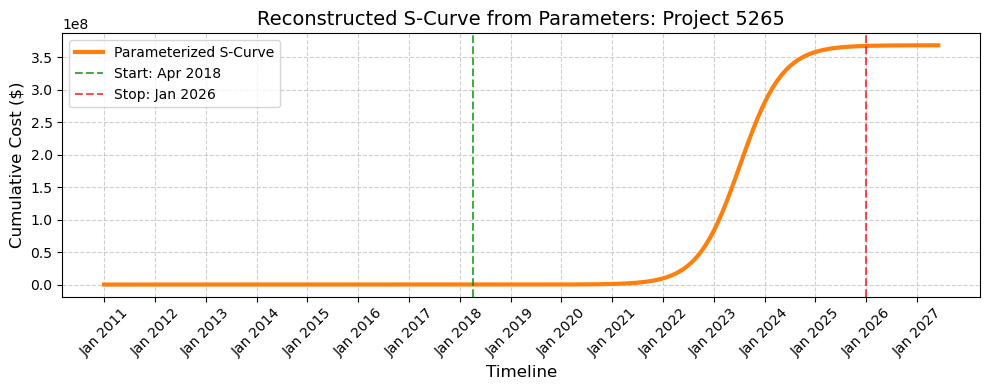

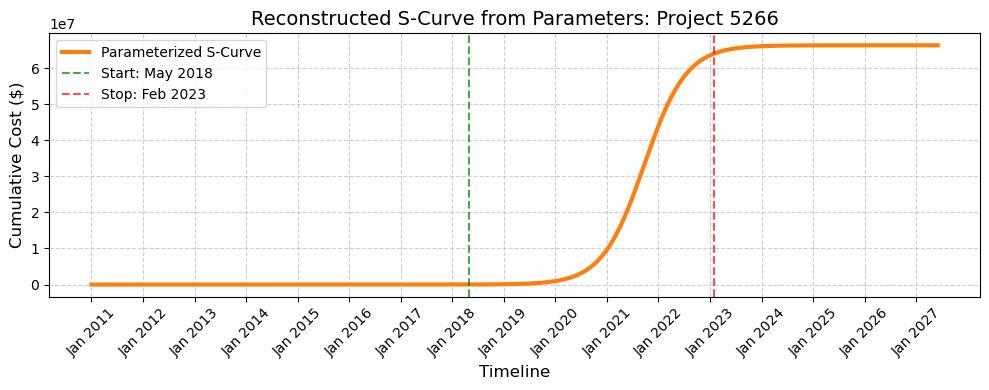

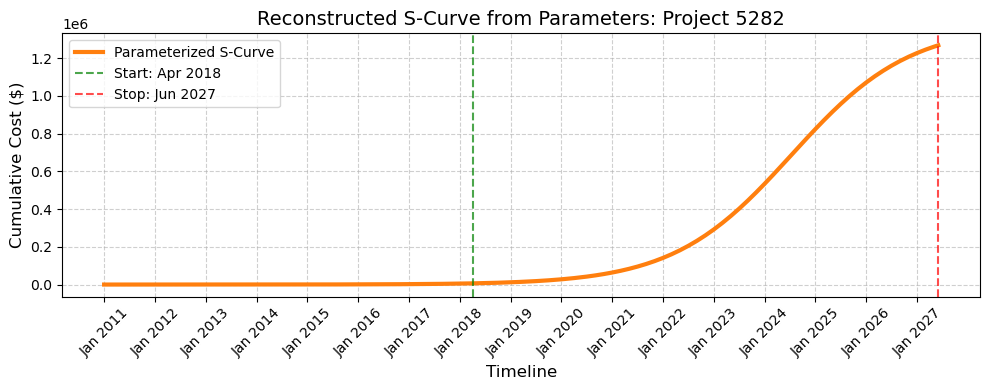

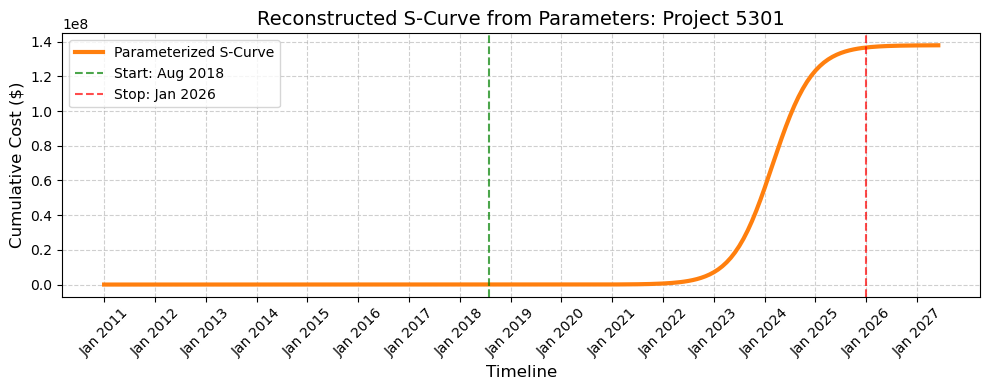

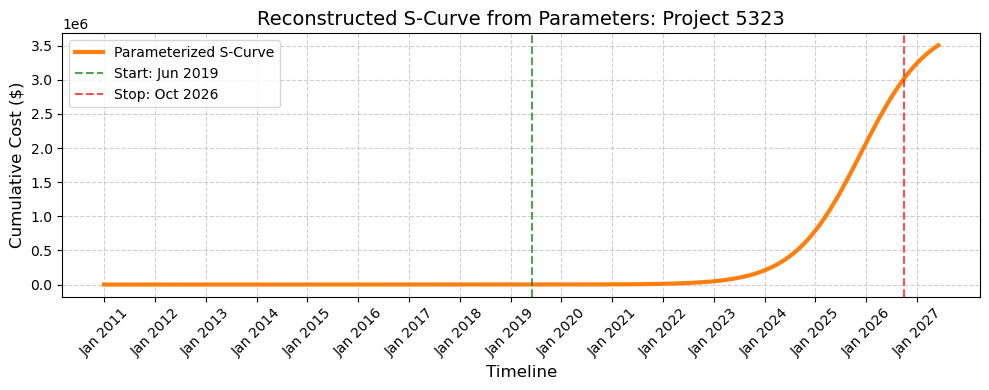

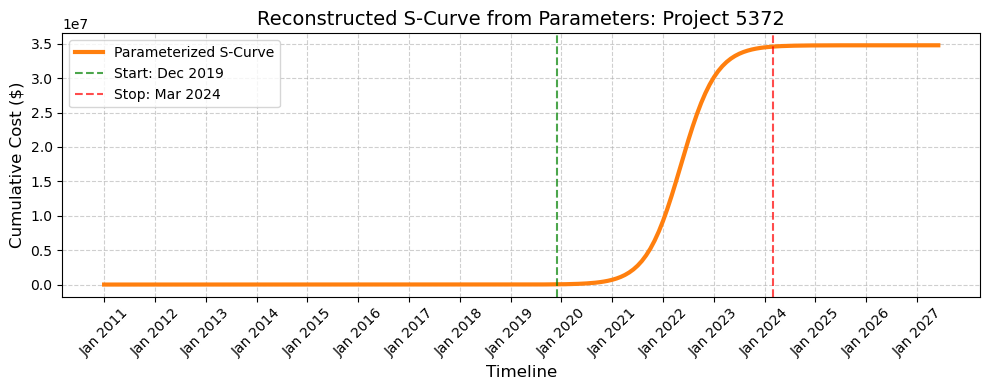

/var/folders/2j/cqg4vj2n1617_3jwzl8fvjnh0000gn/T/ipykernel_38184/1818820531.py:19: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (t - t0)))


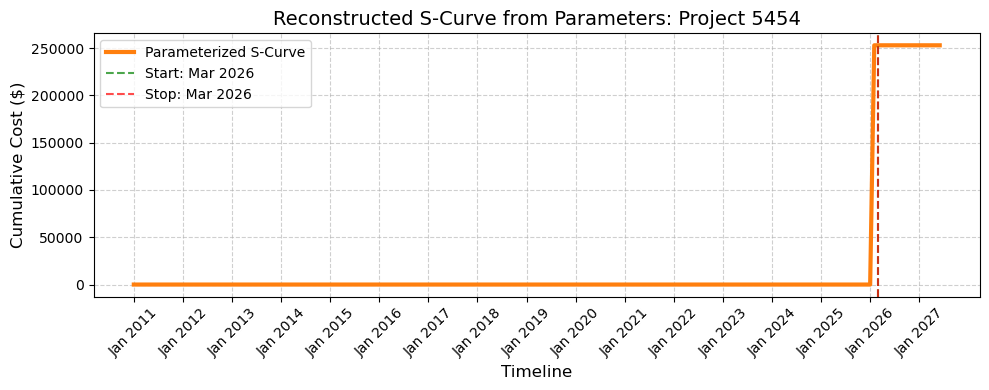

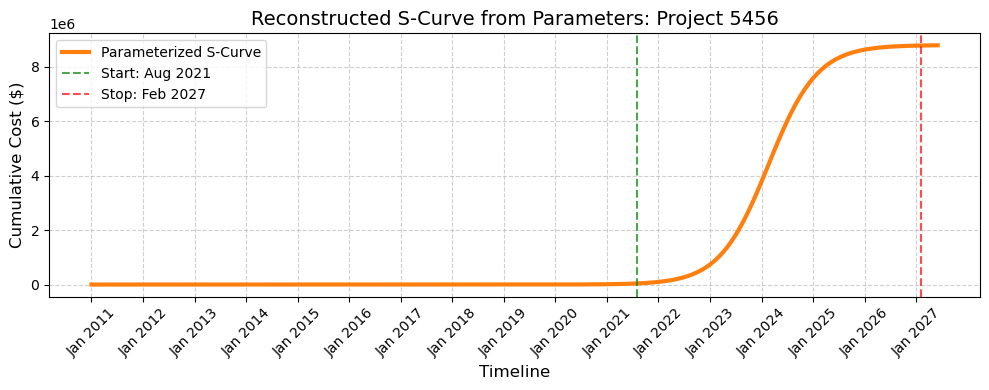

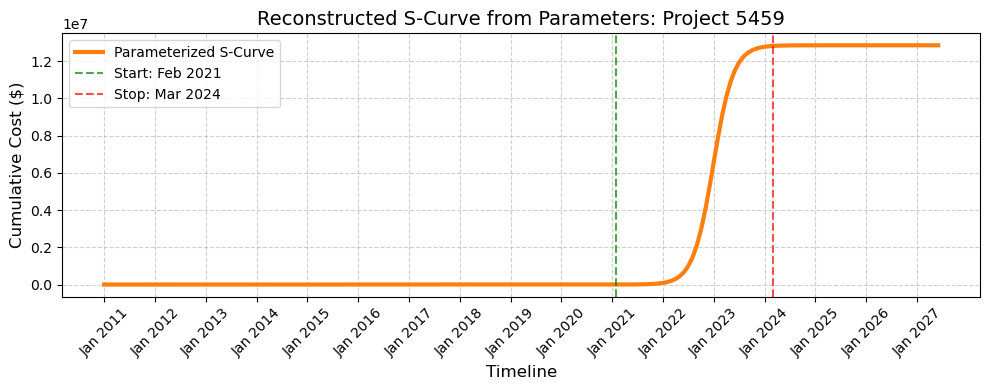

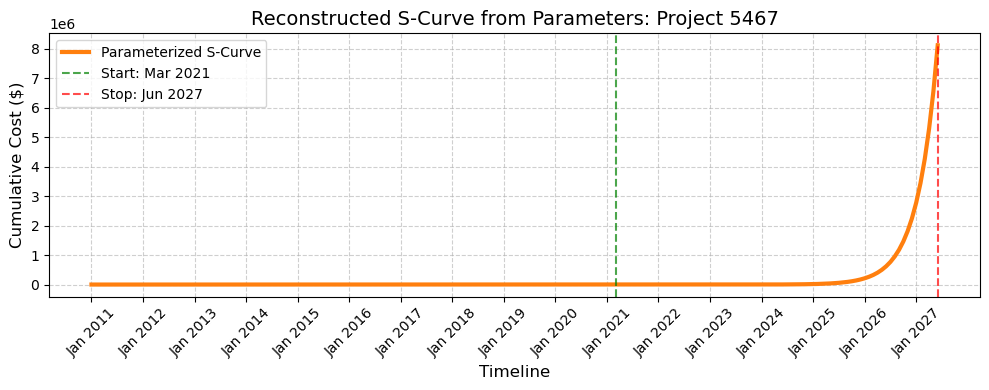

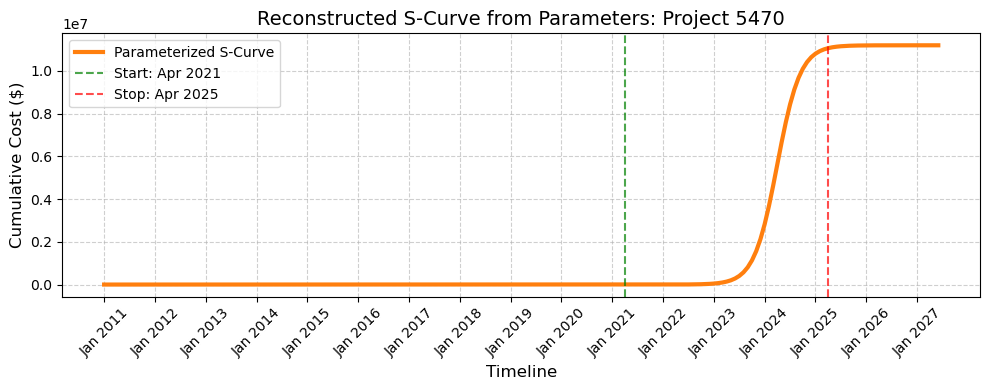

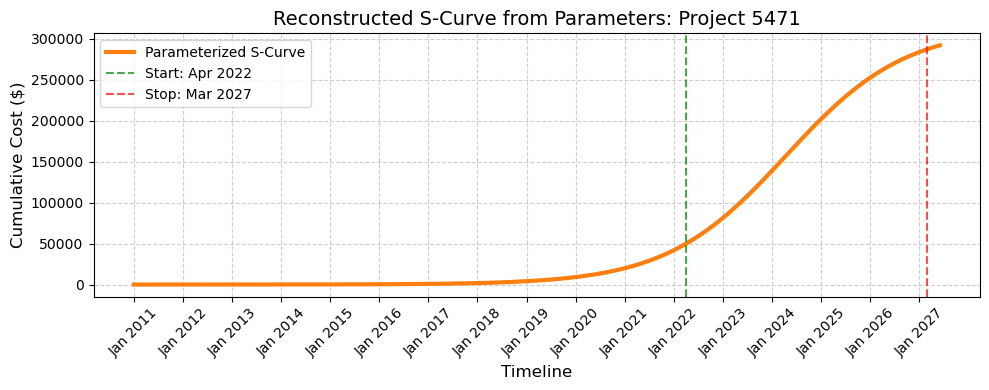

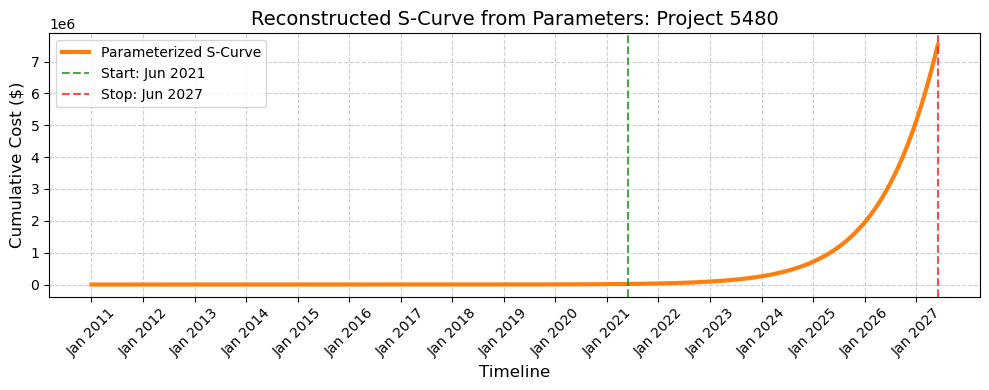

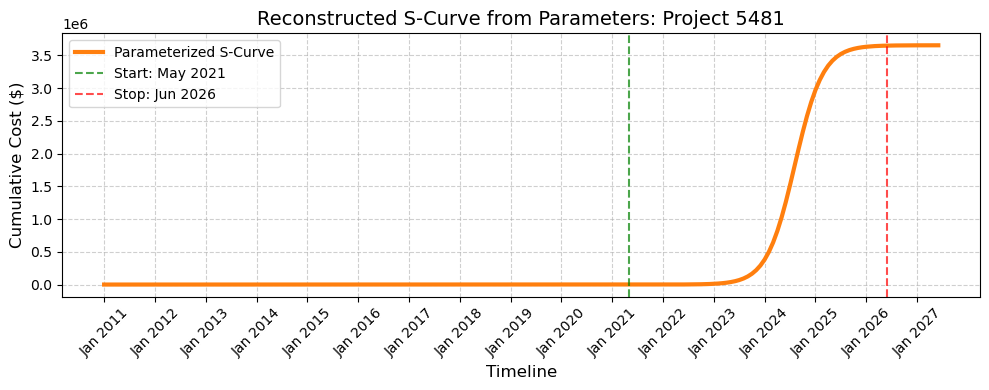

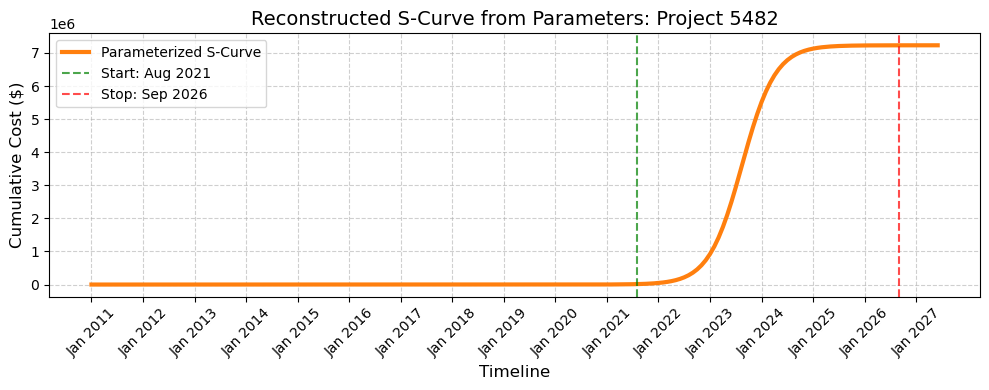

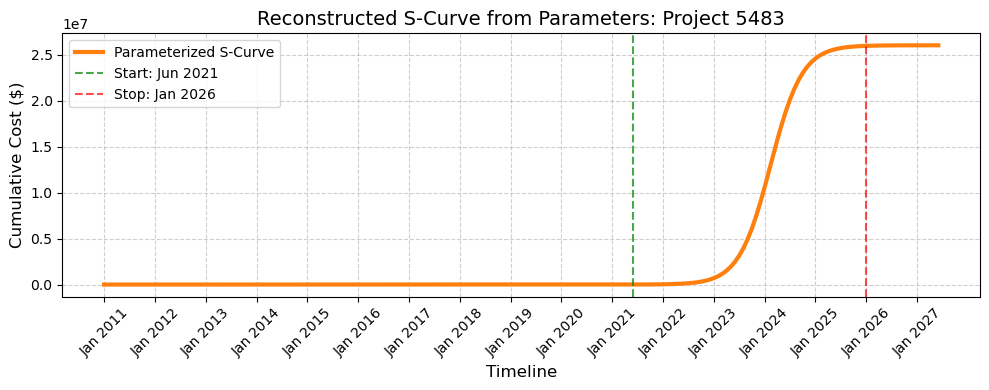

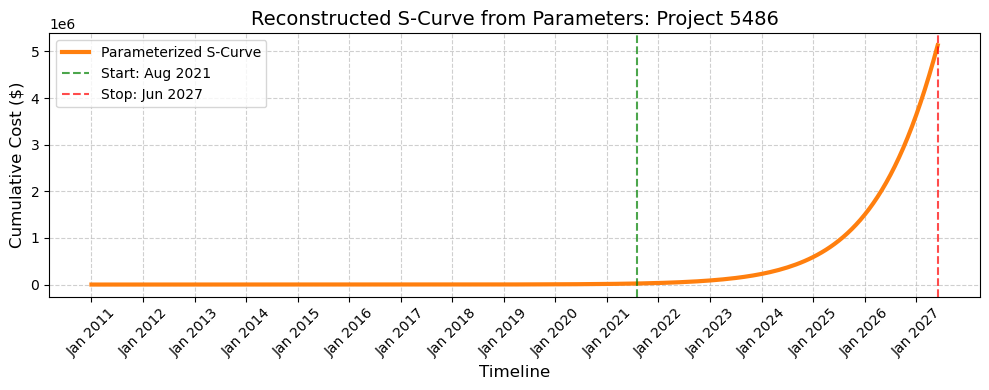

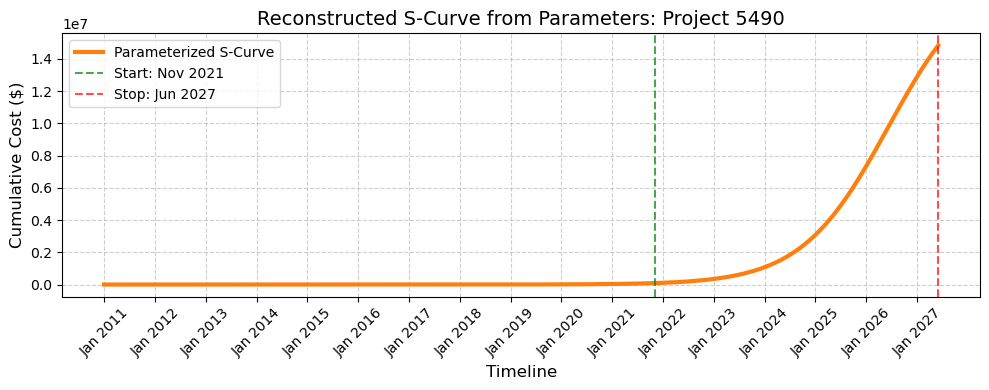

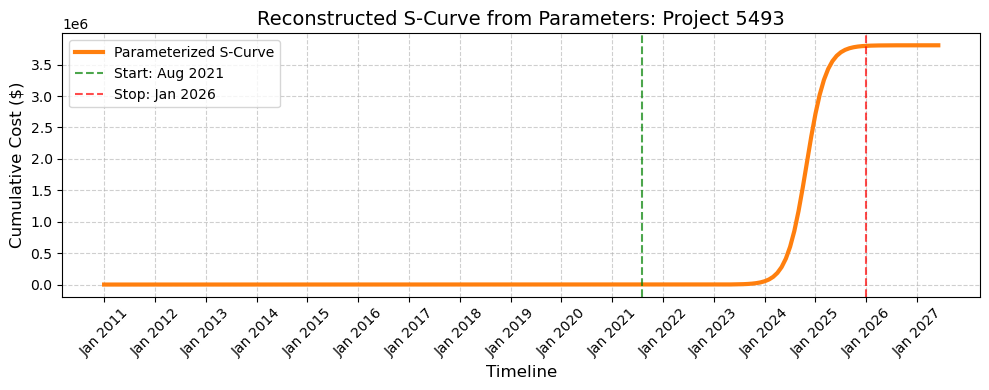

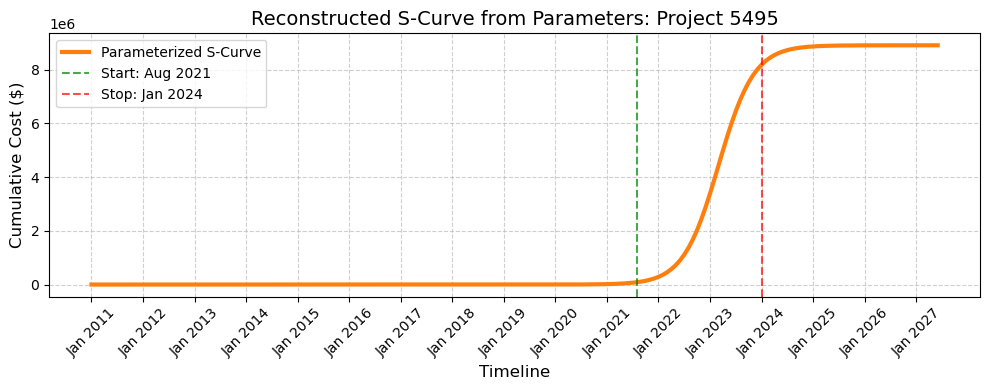

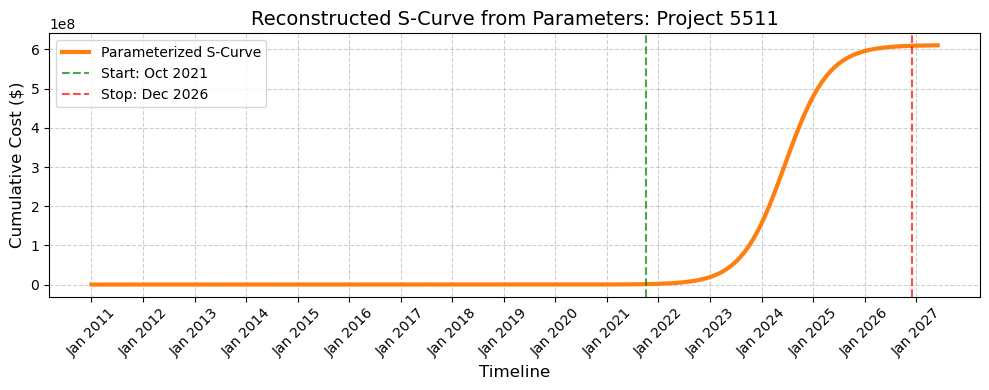

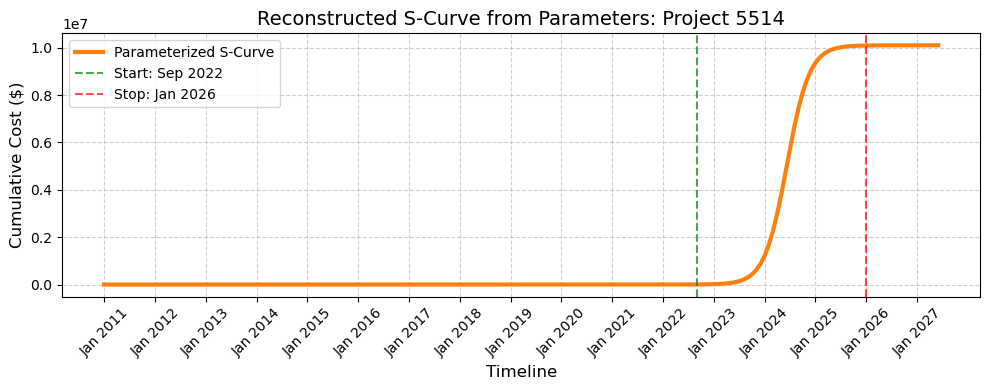

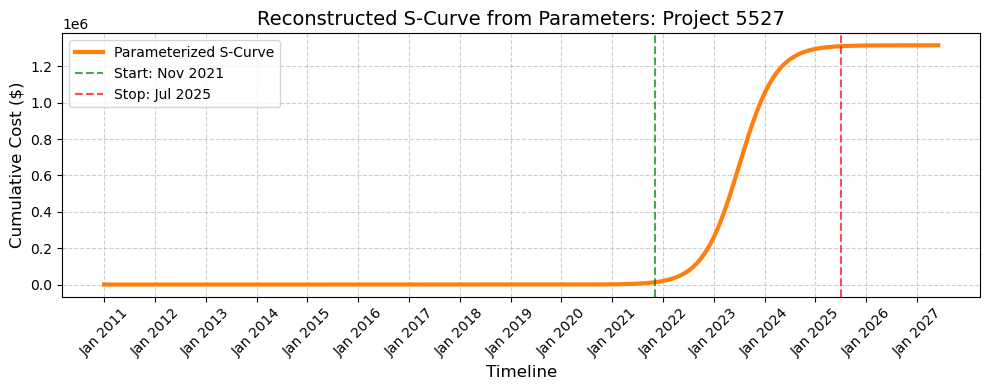

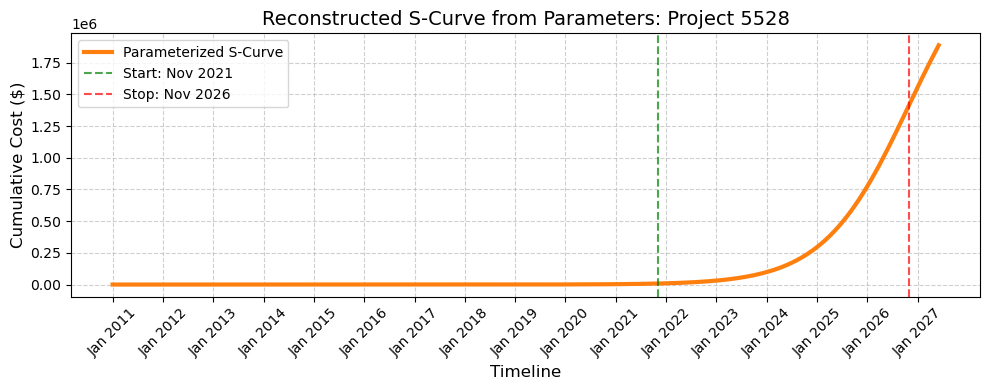

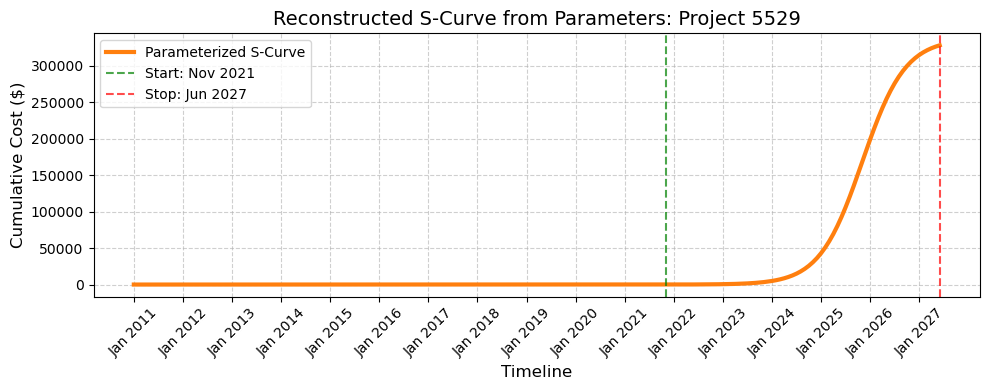

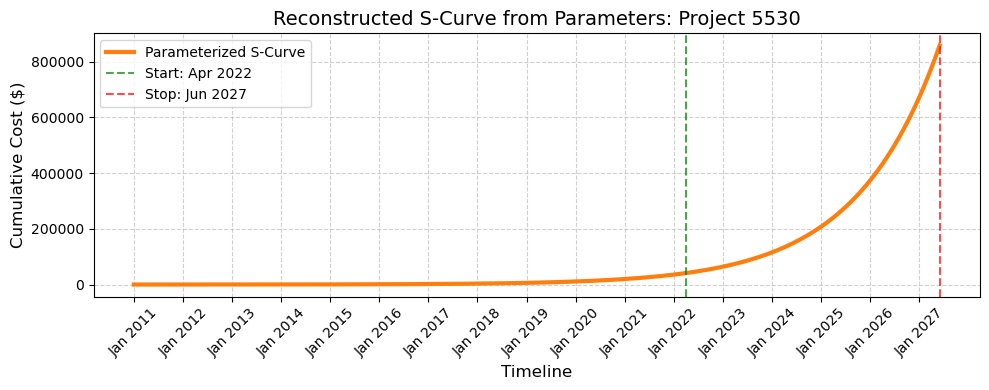

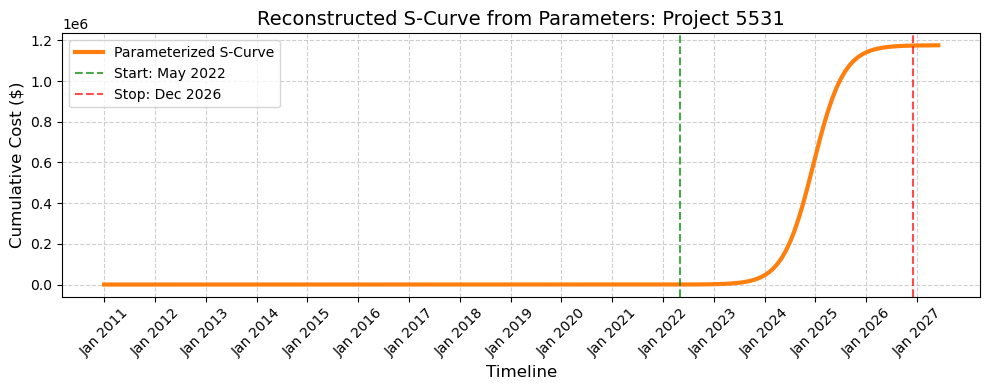

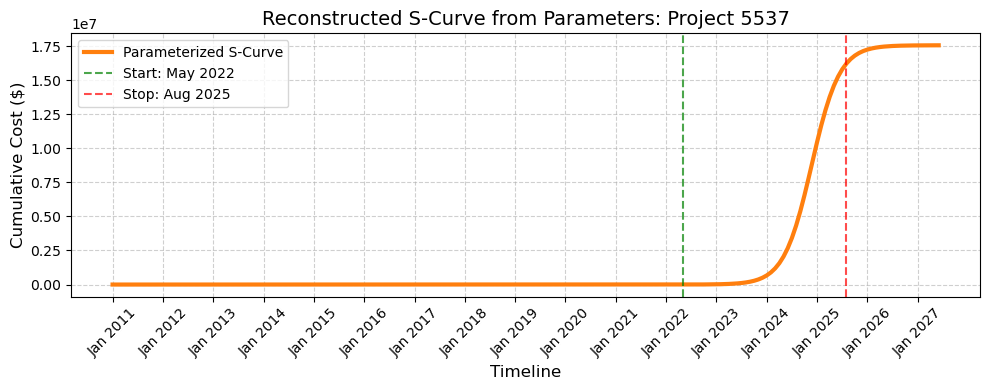

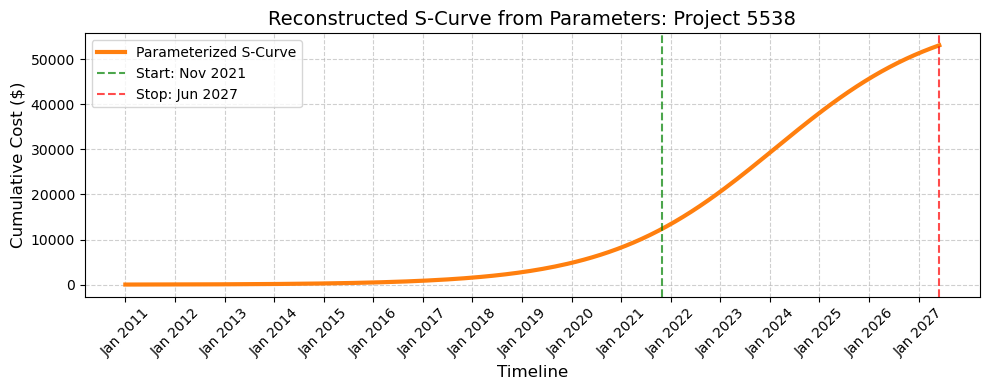

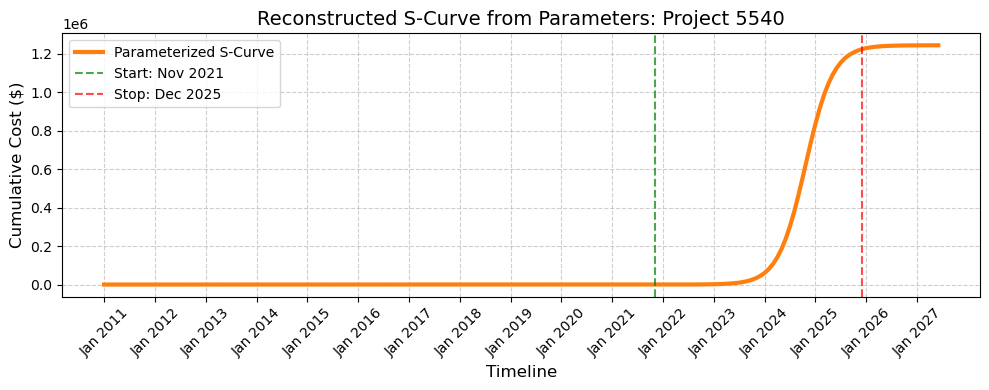

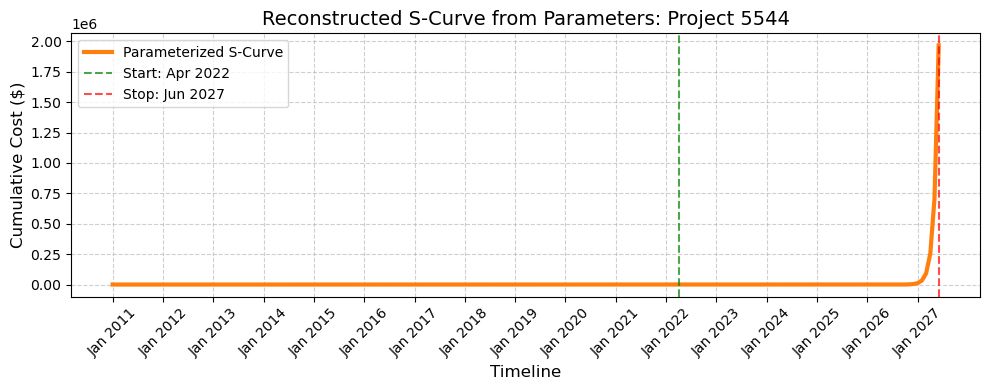

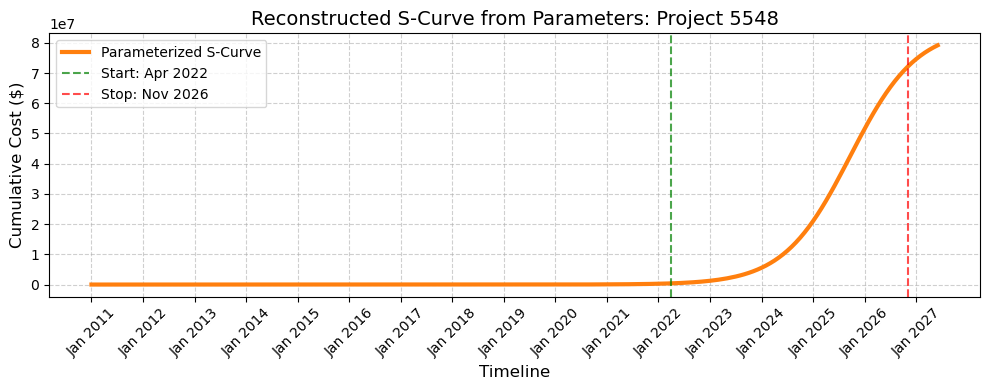

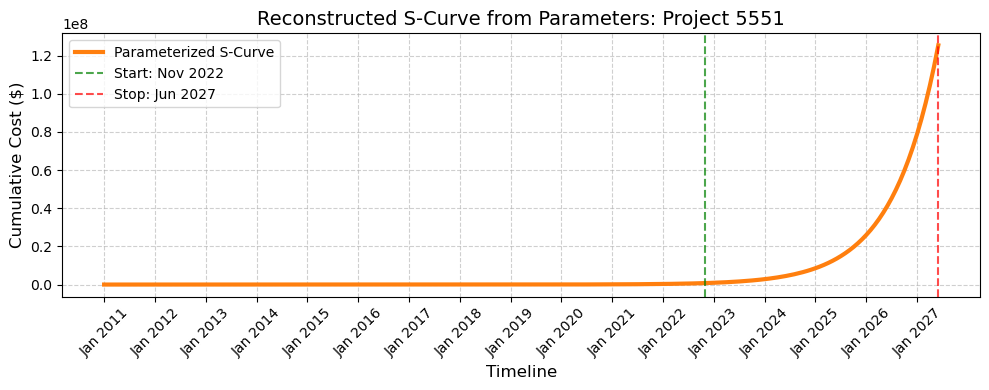

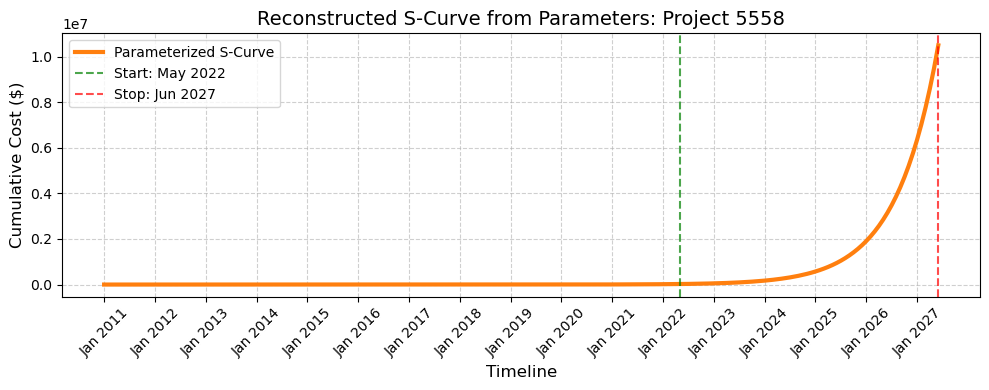

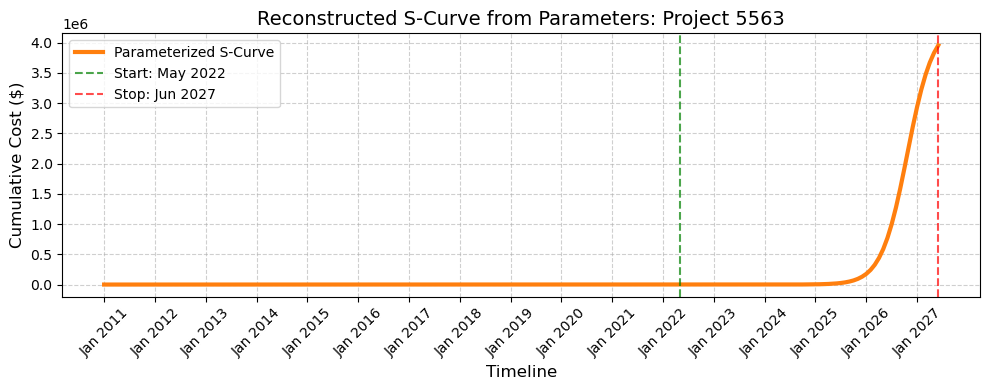

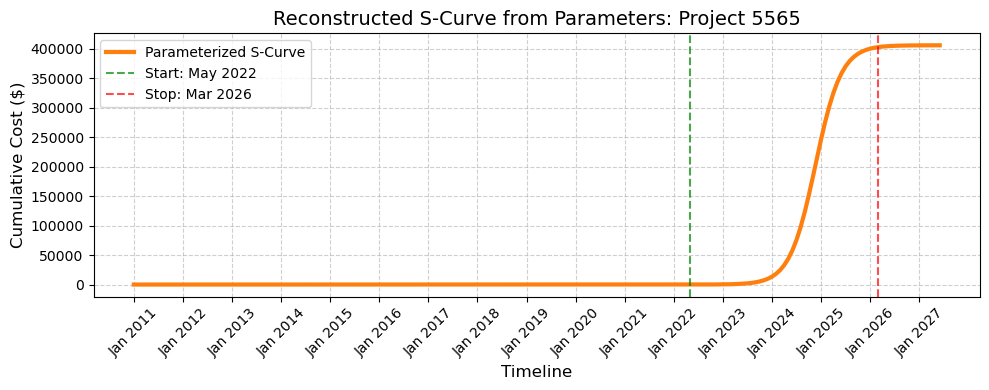

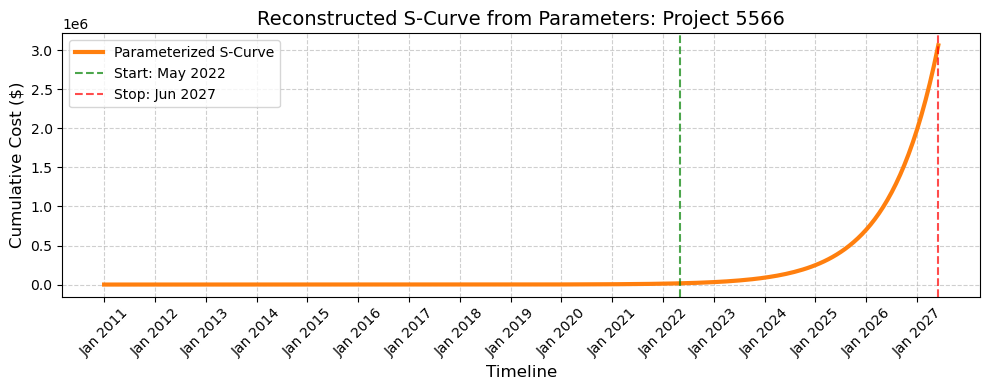

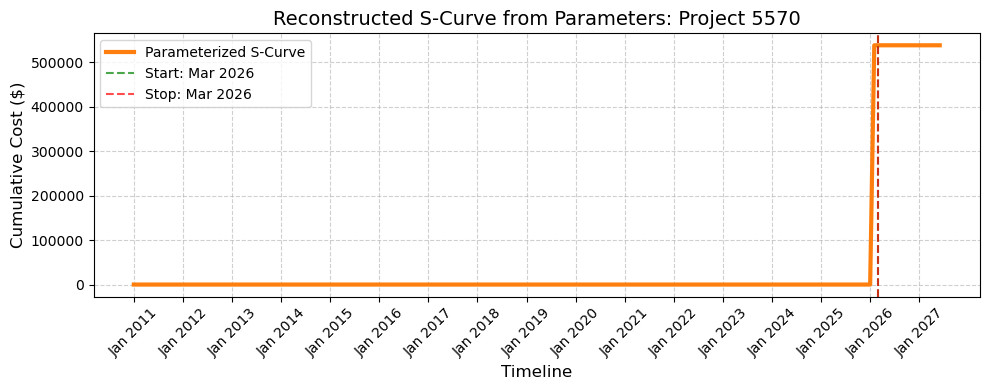

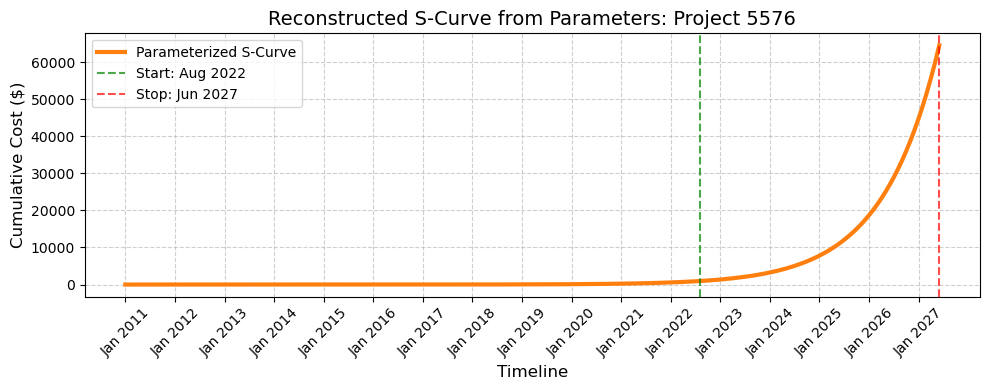

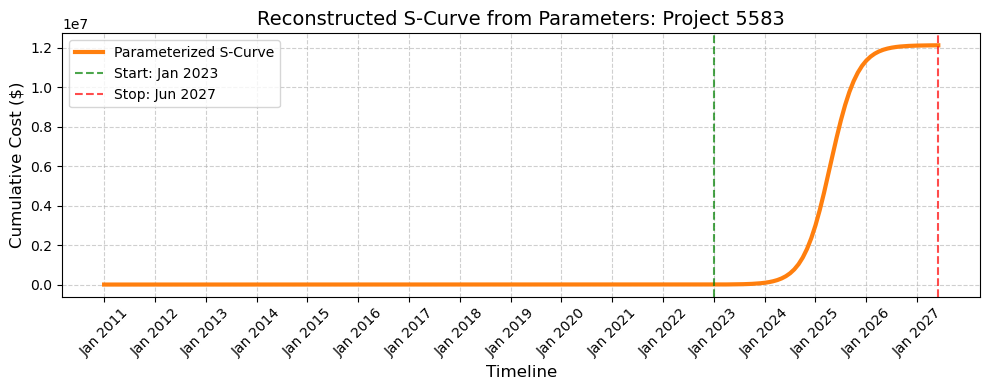

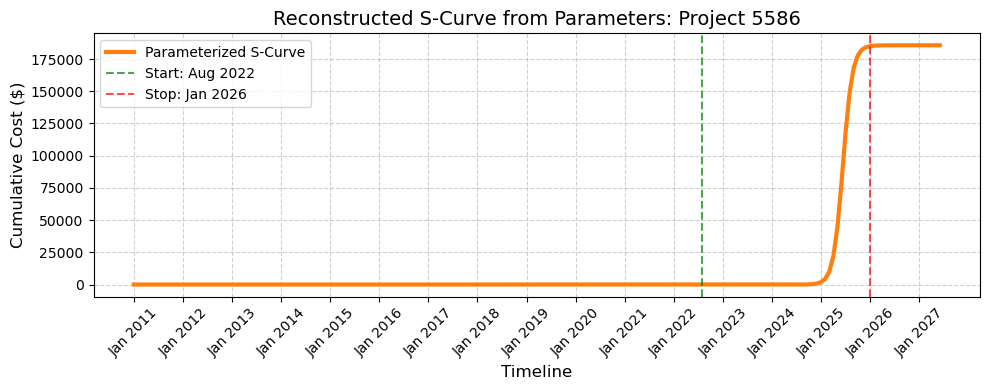

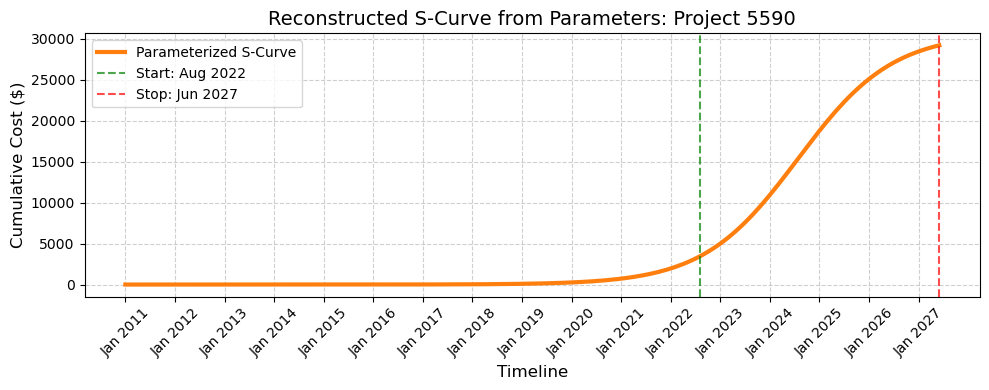

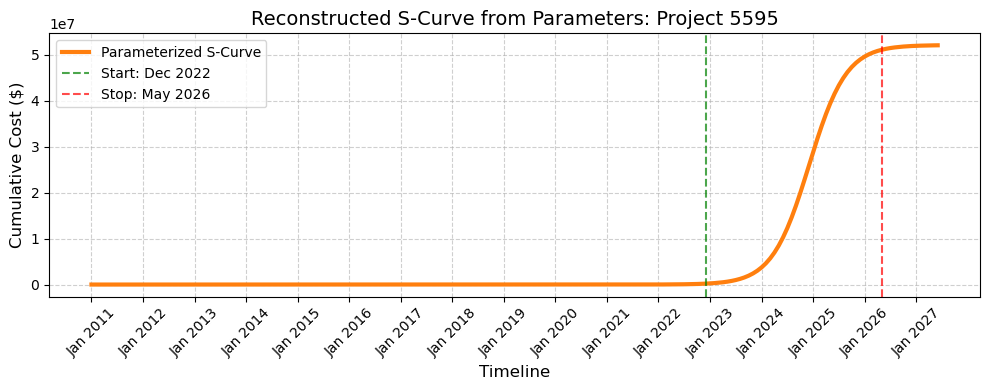

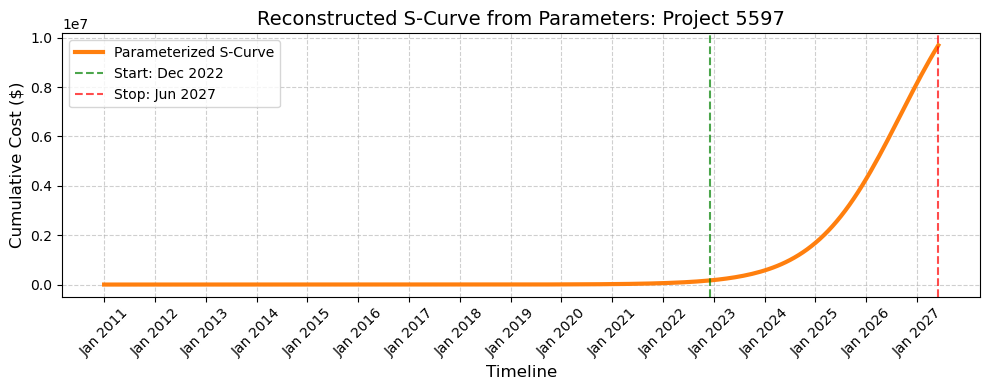

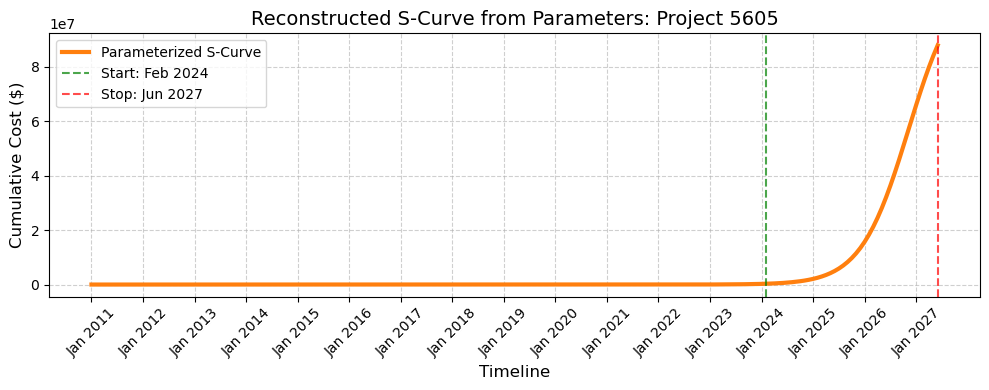

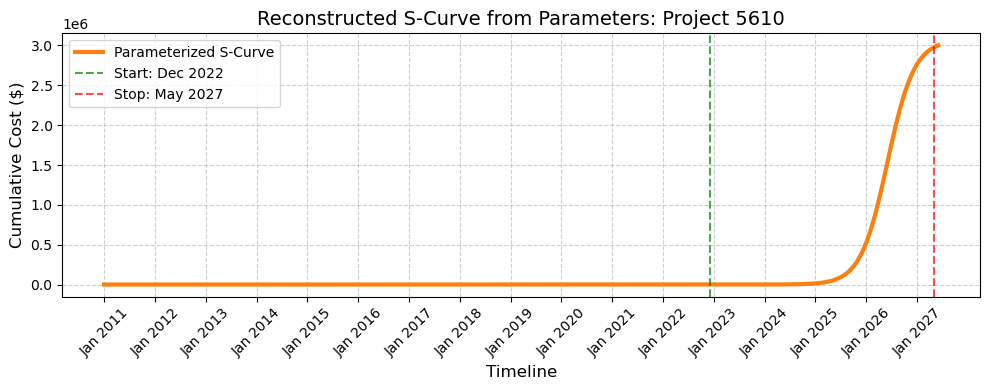

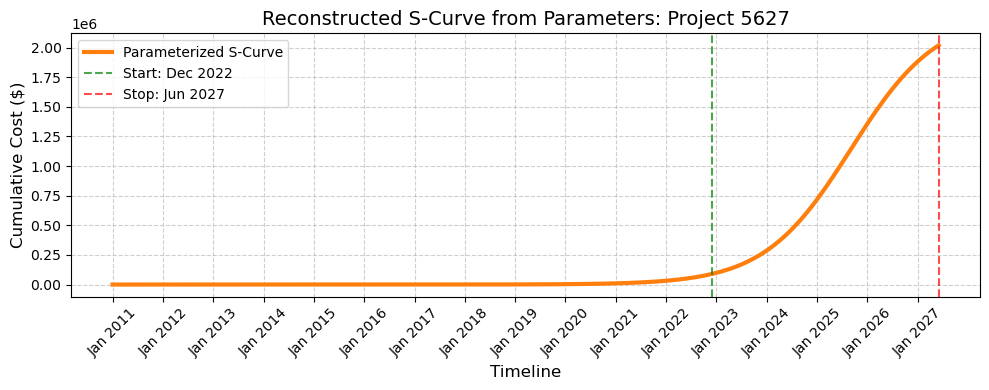

In [12]:
########################################################
"""

Deconstructs timelines into parameters "Start_Date", "Stop_Date", "S_Curve_L" (Max Value),
"S_Curve_k" (Growth Rate), and "S_Curve_t0" (Midpoint), then reconstructs S-curves using 
these parameters (instead of counting cumulative sums)

This version is intended as a proof-of-concept, to show how the parameterization/reconstruction
works. Since in the actual model we're not predicting things like when the project starts, we're
gonna use the version in the next cell

"""
########################################################

all_projects_df_1 = all_projects_df.copy()

# Define our S-curve mathematical model
def logistic_curve(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))

# Prepare our X-axis as numeric time steps
timeline_cols = all_projects_df_1.columns[5:]
x_data = np.arange(len(timeline_cols))

# Create empty lists to store all our parameters
L_params = []
k_params = []
t0_params = []
start_dates = []
stop_dates = []

# Loop through the projects
for index, row in all_projects_df_1.iterrows():
    y_data = row[timeline_cols].values.astype(float)
    start_idx = np.argmax(y_data > 0)
    stop_idx = np.argmax(y_data == y_data[-1])
    start_dates.append(timeline_cols[start_idx])
    stop_dates.append(timeline_cols[stop_idx])

    # Fit the Logistic Curve (same as before)
    initial_guess = [y_data[-1], 0.1, len(x_data)/2]
    popt, pcov = curve_fit(logistic_curve, x_data, y_data, p0=initial_guess, maxfev=1000000)
        
    L_params.append(popt[0])
    k_params.append(popt[1])
    t0_params.append(popt[2])

# Save all these features as new columns in our dataframe
all_projects_df_1['S_Curve_L'] = L_params
all_projects_df_1['S_Curve_k'] = k_params
all_projects_df_1['S_Curve_t0'] = t0_params
all_projects_df_1['Start_Date'] = start_dates
all_projects_df_1['Stop_Date'] = stop_dates

# Check results in table
display(all_projects_df_1[['Project Code', 'Start_Date', 'Stop_Date', 'S_Curve_L', 'S_Curve_k', 'S_Curve_t0']].head(60))

# Set up our timeline and X-axis indices
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()
x_data = np.arange(len(timeline_cols))

# Loop through the first 3 projects
for index, row in all_projects_df_1.head(60).iterrows():
    L = row['S_Curve_L']
    k = row['S_Curve_k']
    t0 = row['S_Curve_t0']
    start = row['Start_Date']
    stop = row['Stop_Date']
        
    # Generate curve using parameters
    predicted_y = logistic_curve(x_data, L, k, t0)
    plt.figure(figsize=(10, 4))
    plt.plot(timeline_cols, predicted_y, linewidth=3, color='#ff7f0e', label="Parameterized S-Curve")
    
    # Formatting
    if pd.notna(start) and pd.notna(stop):
        start_idx = timeline_cols.index(start)
        stop_idx = timeline_cols.index(stop)
        plt.axvline(x=start_idx, color='green', linestyle='--', alpha=0.7, label=f"Start: {start}")
        plt.axvline(x=stop_idx, color='red', linestyle='--', alpha=0.7, label=f"Stop: {stop}")

    plt.title(f"Reconstructed S-Curve from Parameters: Project {row['Project Code']}", fontsize=14)
    plt.xlabel("Timeline", fontsize=12)
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.xticks(timeline_cols[::12], rotation=45) 
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

,Project Code,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0
0,4638,129,4.168640e+07,0.186747,107.580958
1,5018,37,6.452617e+04,0.113672,15.090781
2,5046,119,2.668237e+05,0.135722,16.353813
3,5058,67,4.617377e+08,0.197593,38.709869
4,5088,67,1.660232e+08,0.200762,47.672114
5,5105,133,1.509875e+10,0.012344,994.134224
6,5148,120,4.420297e+08,0.139075,98.138398
7,5171,107,5.477962e+08,0.101184,82.457030
8,5198,92,1.247584e+06,0.075928,17.455279
9,5199,95,6.479661e+06,0.060394,56.606855


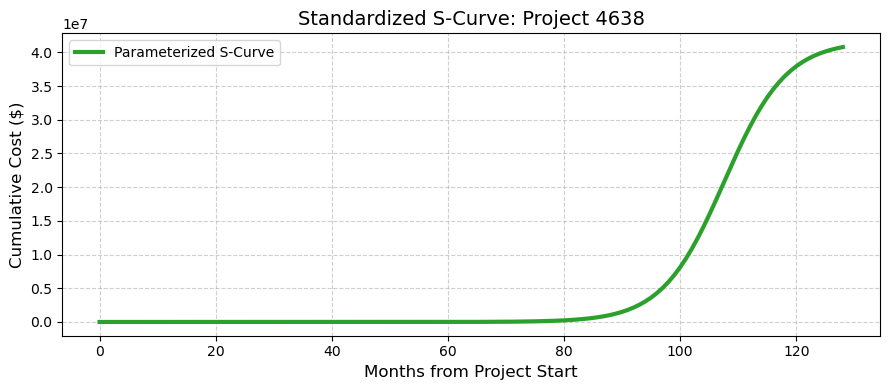

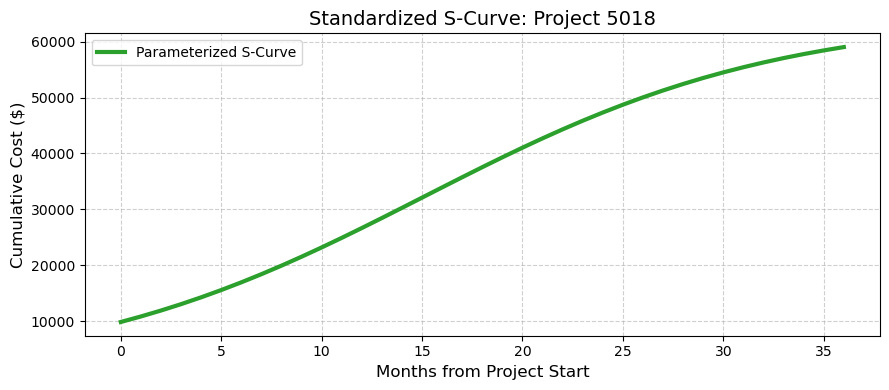

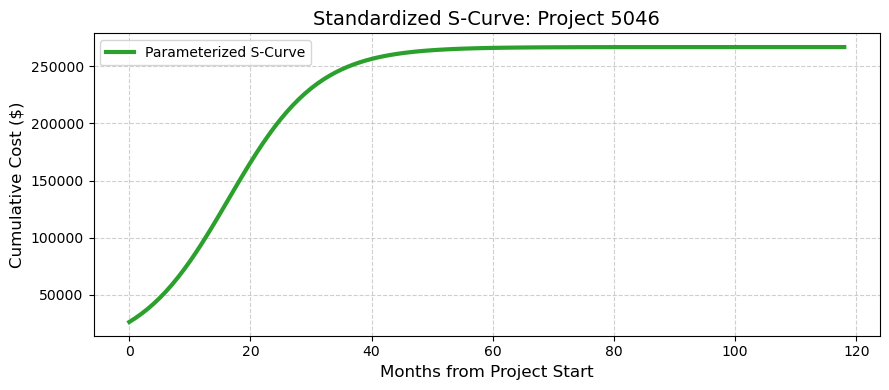

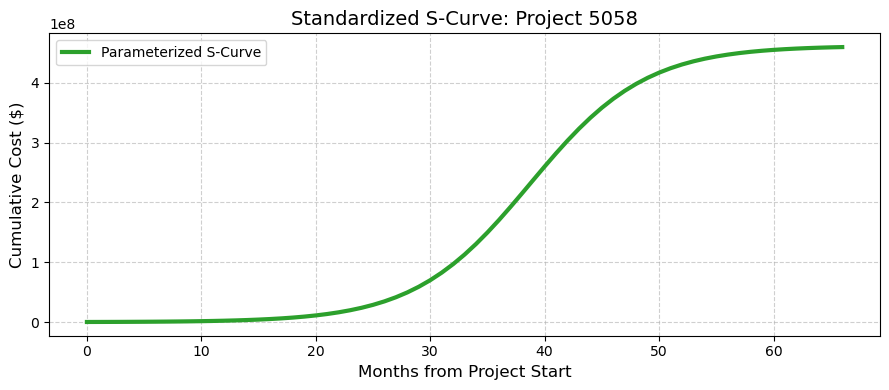

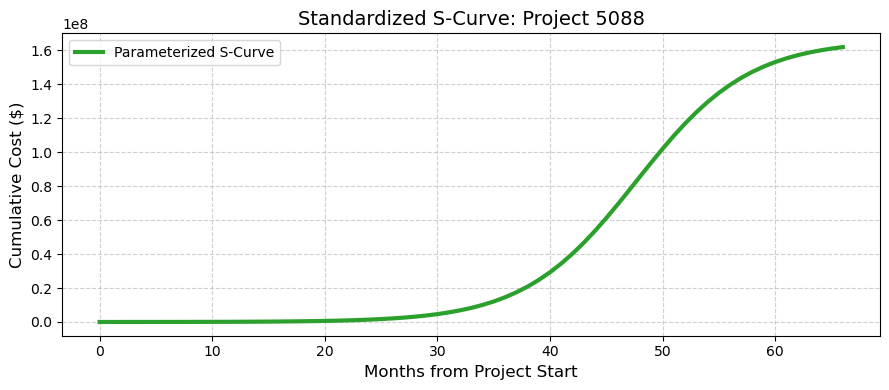

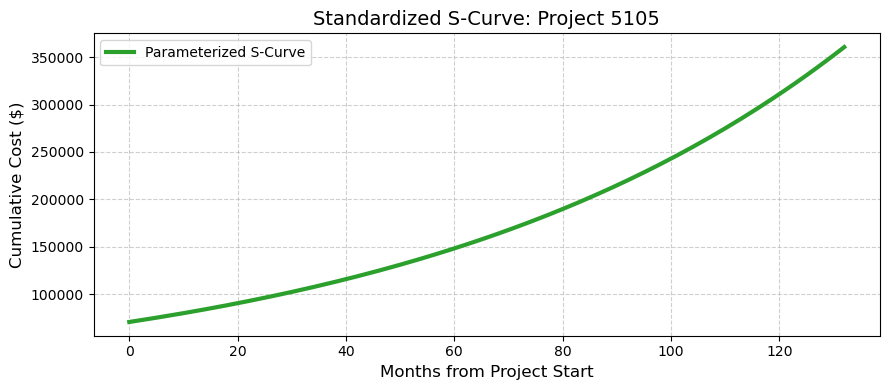

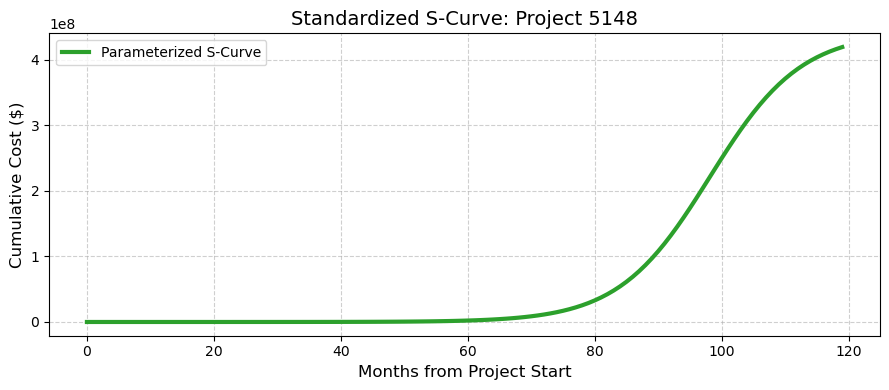

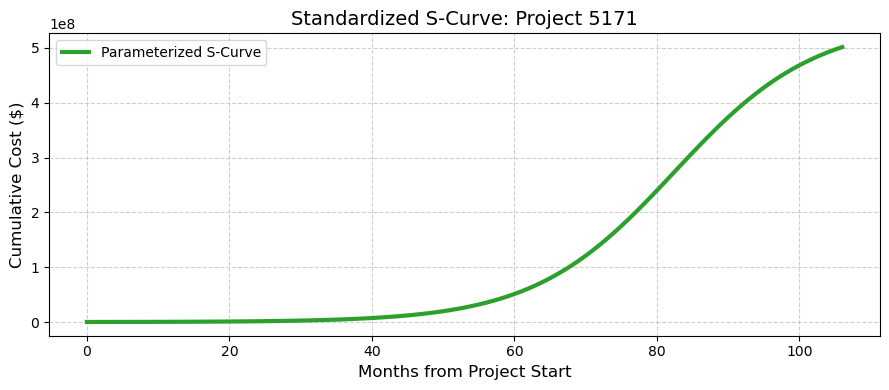

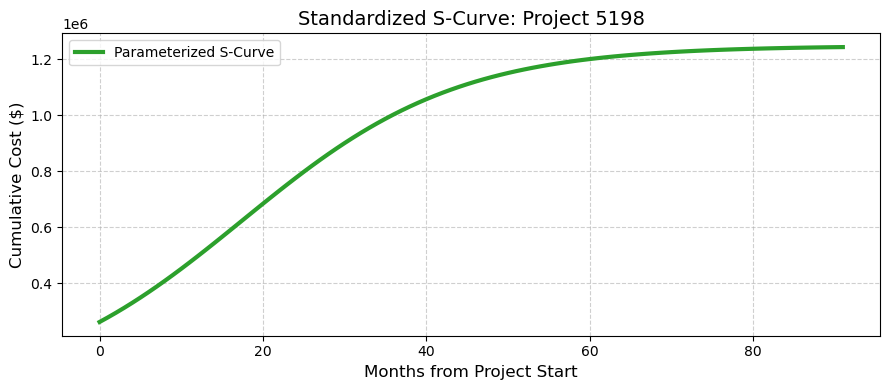

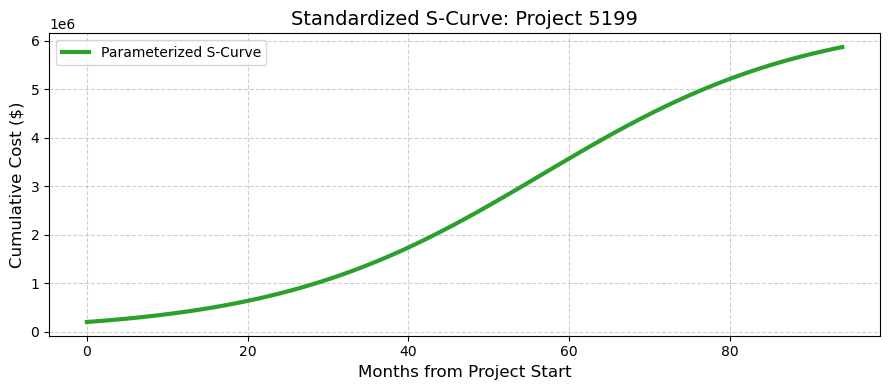

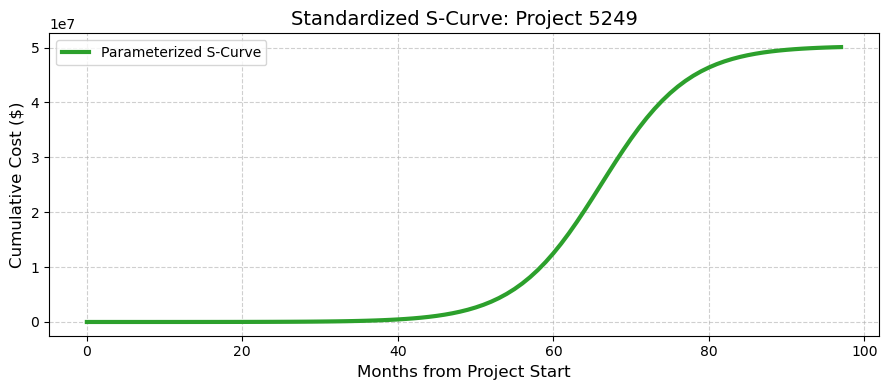

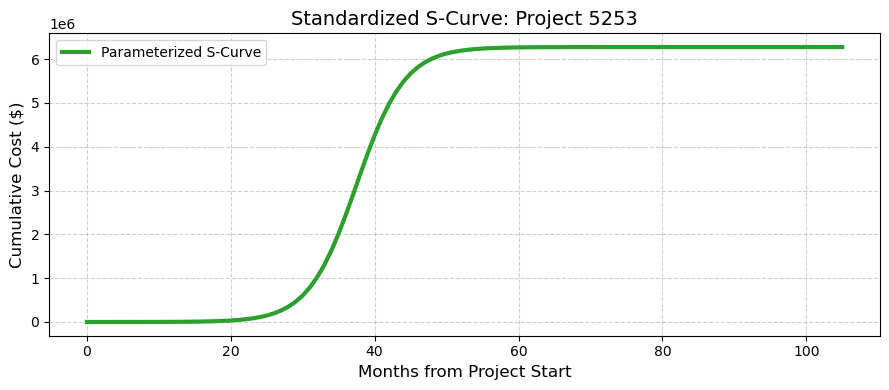

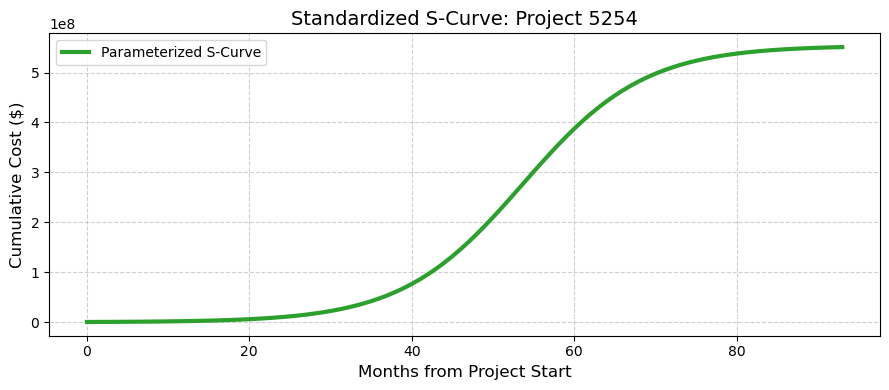

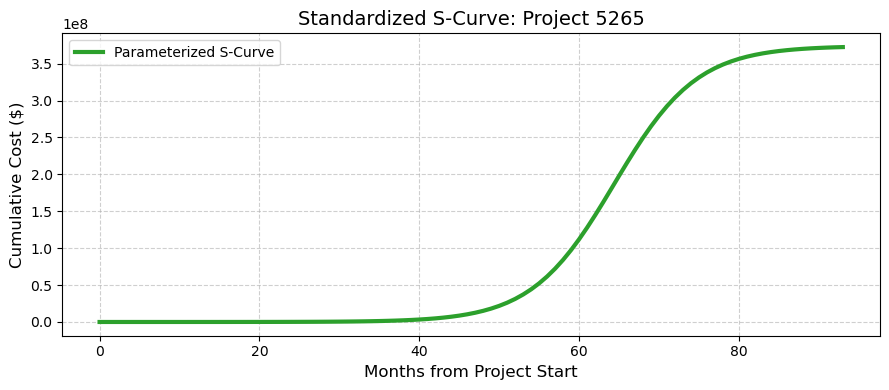

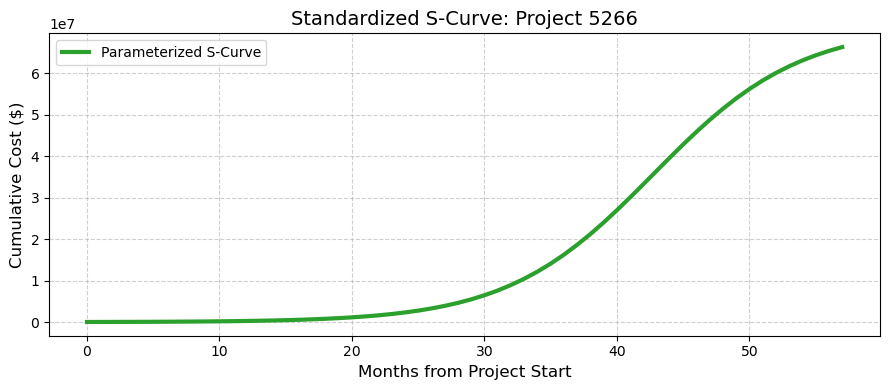

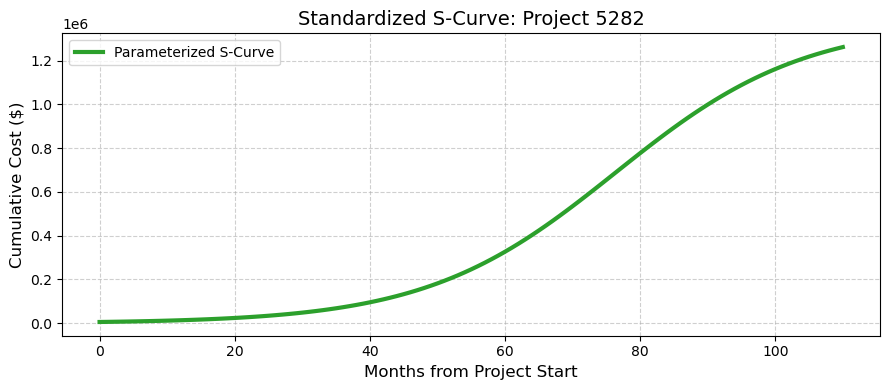

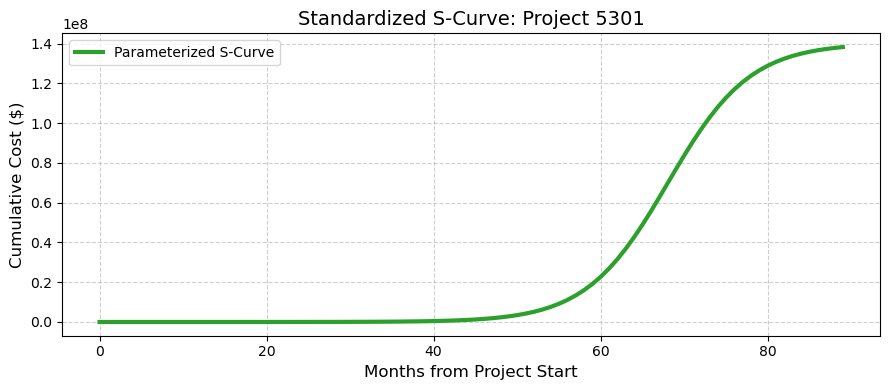

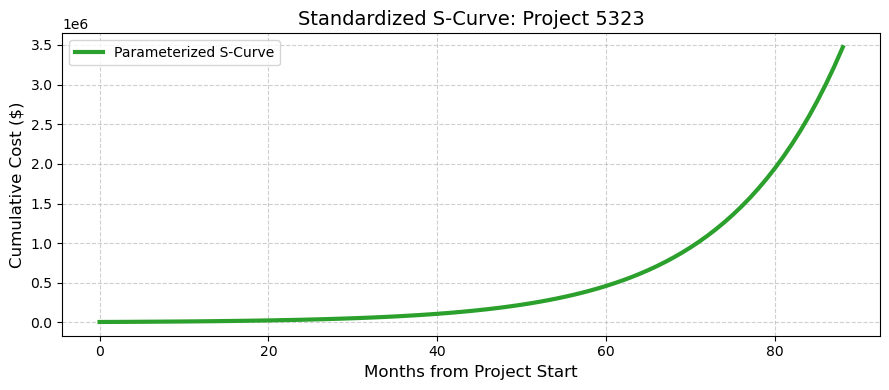

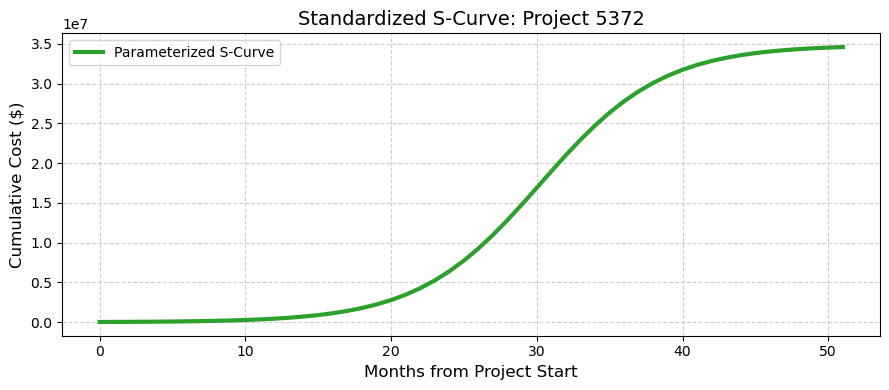

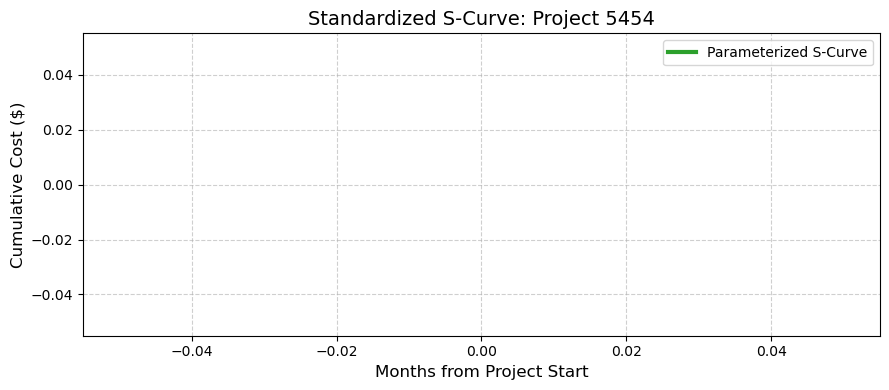

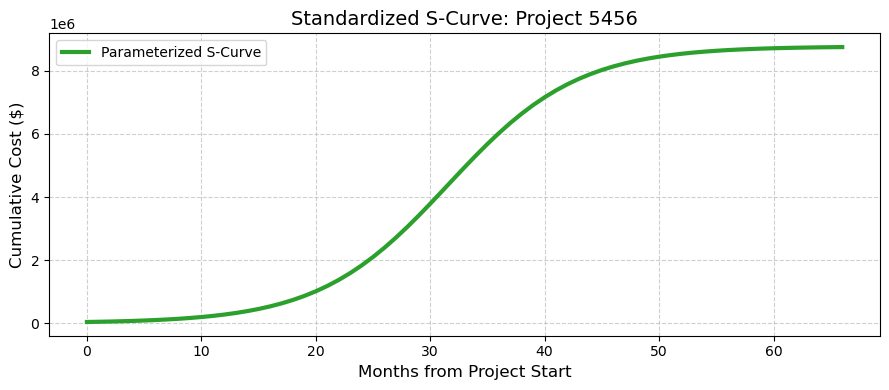

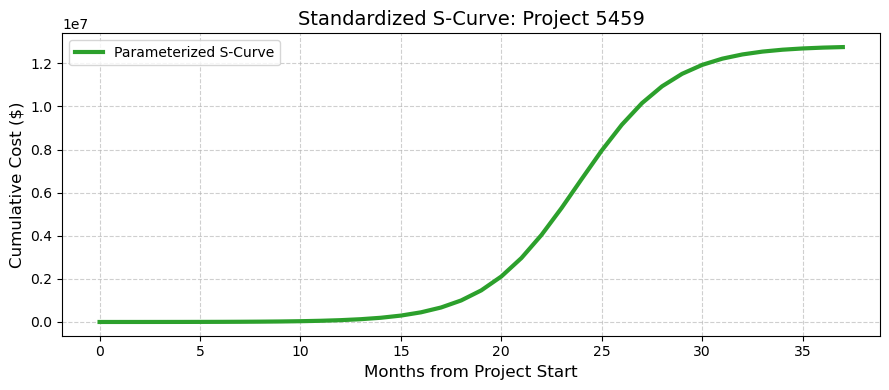

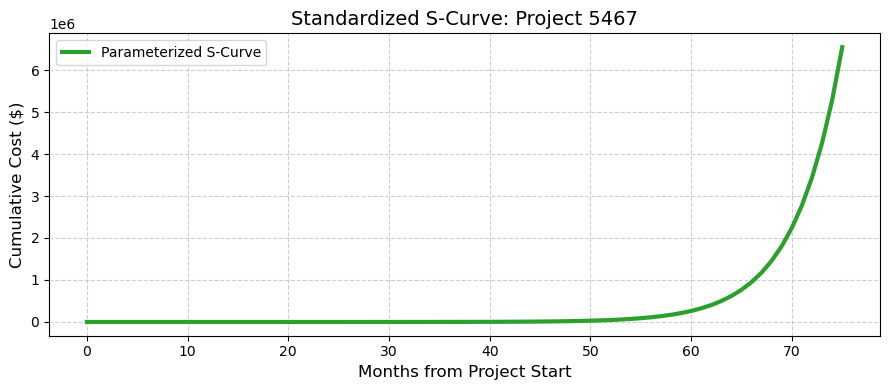

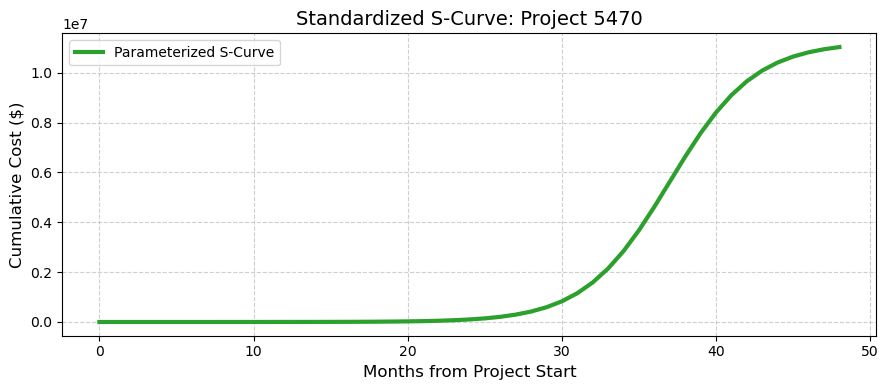

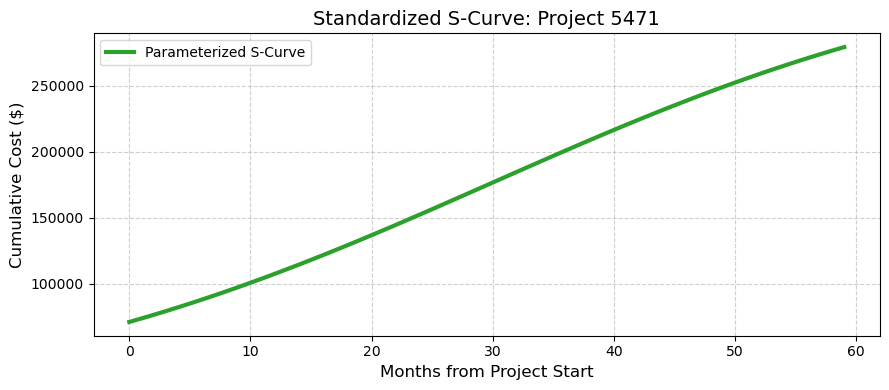

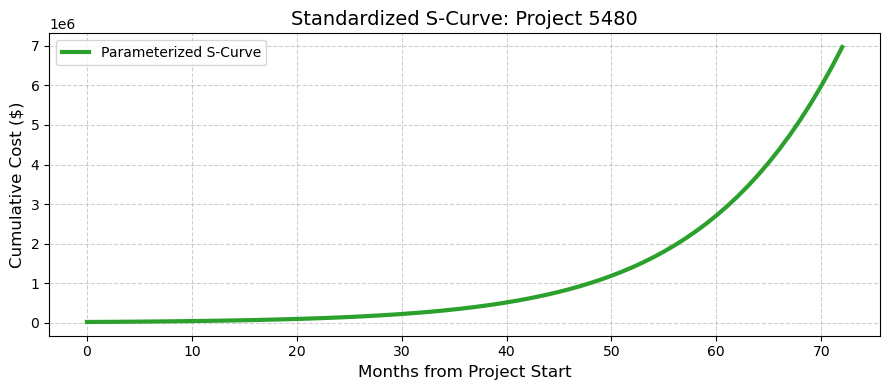

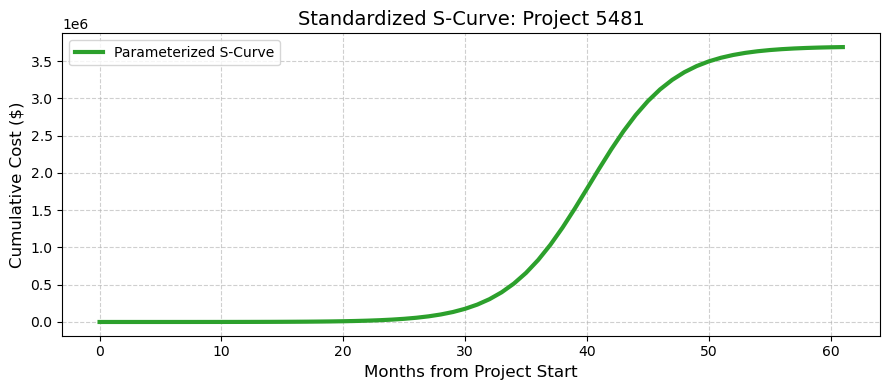

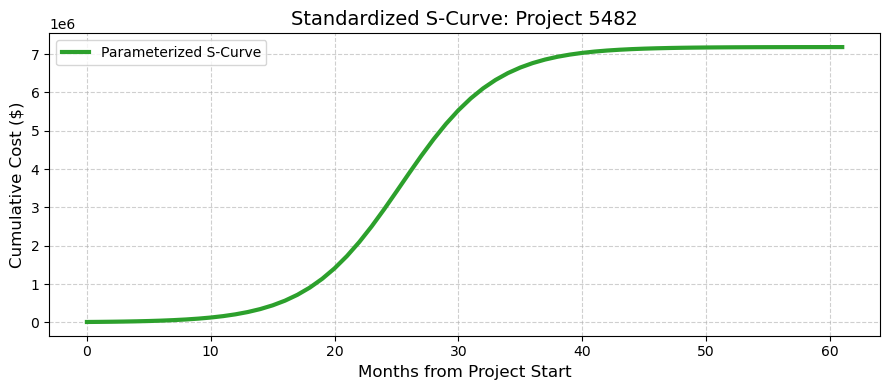

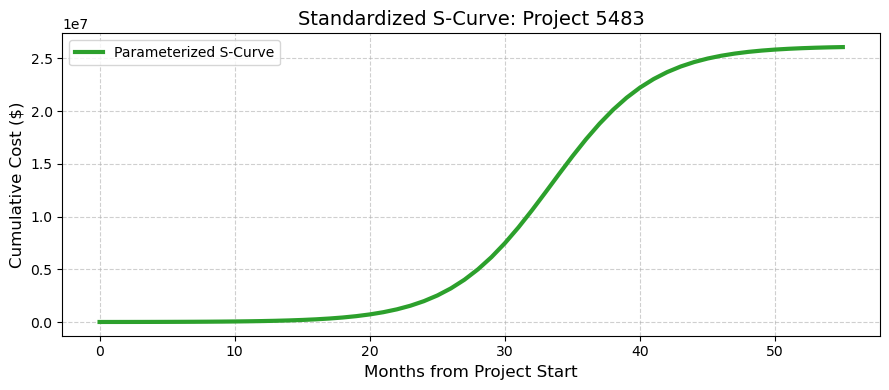

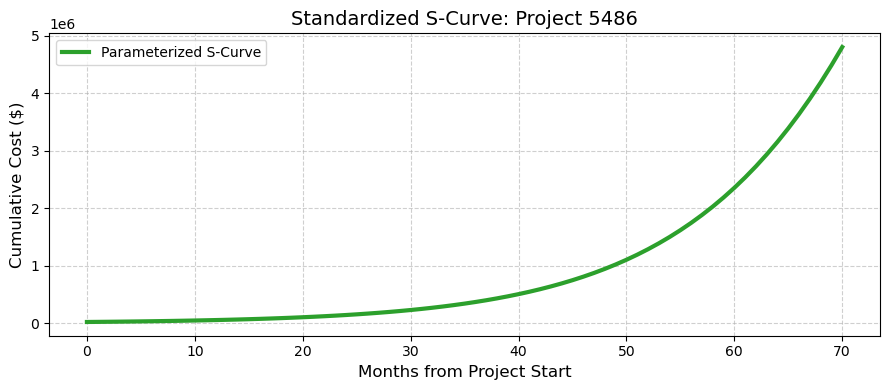

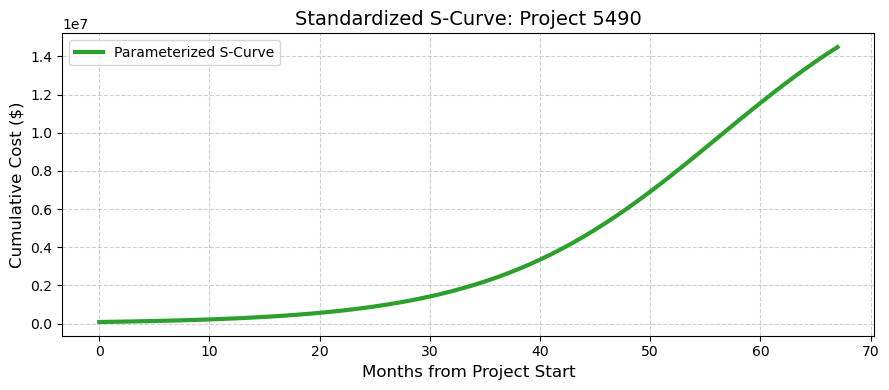

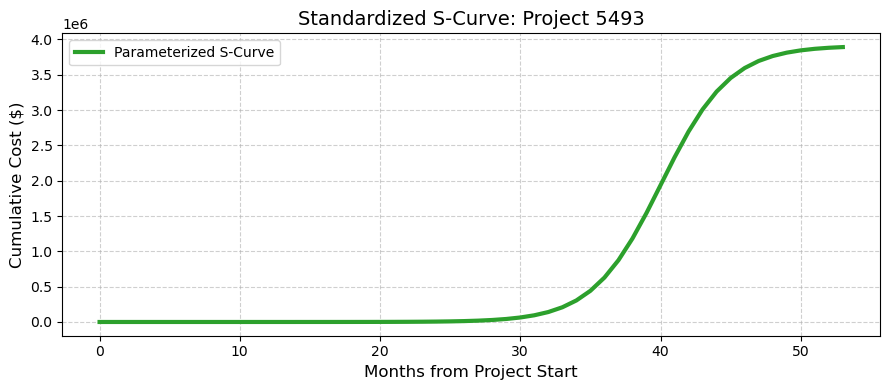

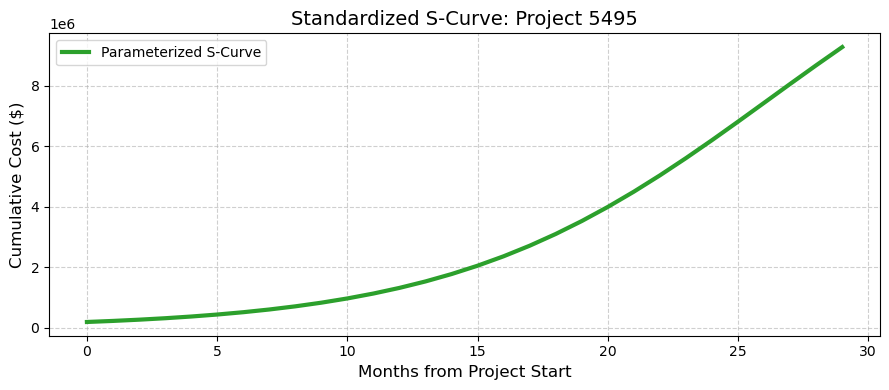

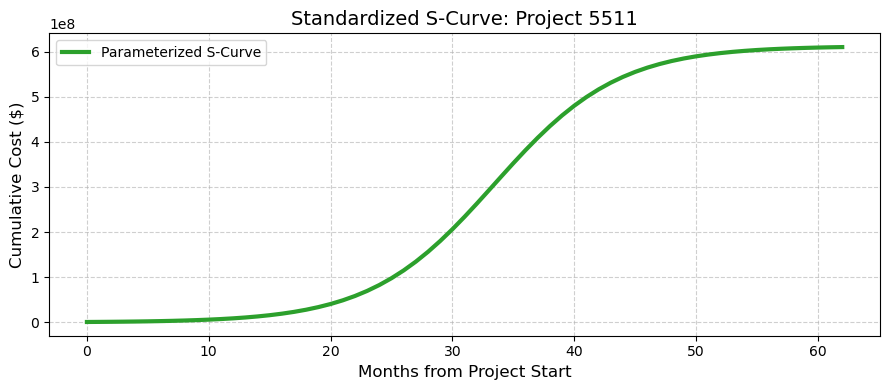

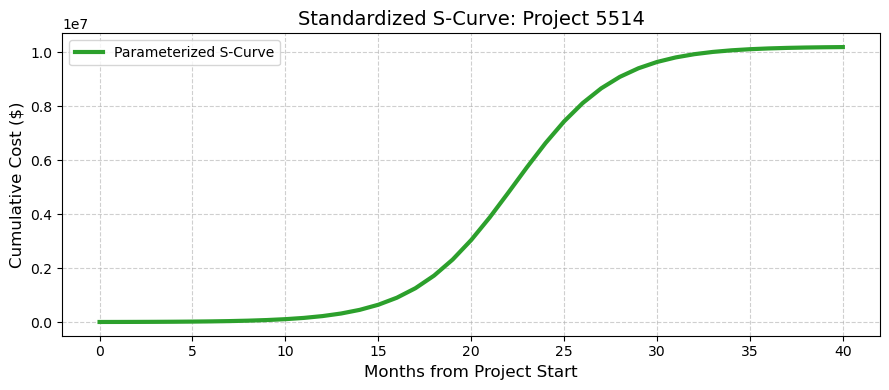

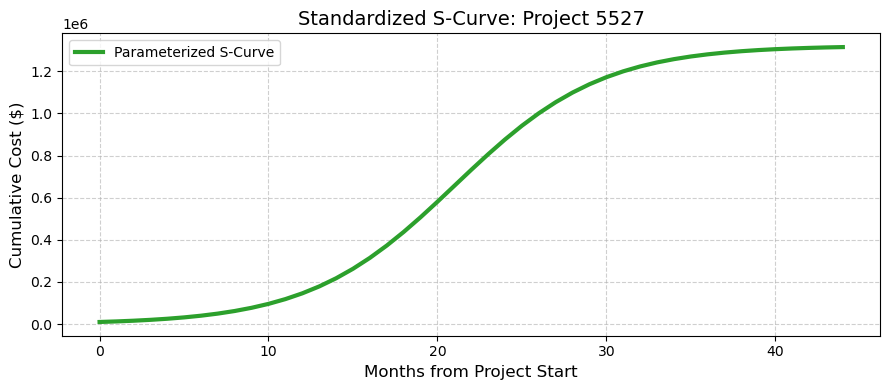

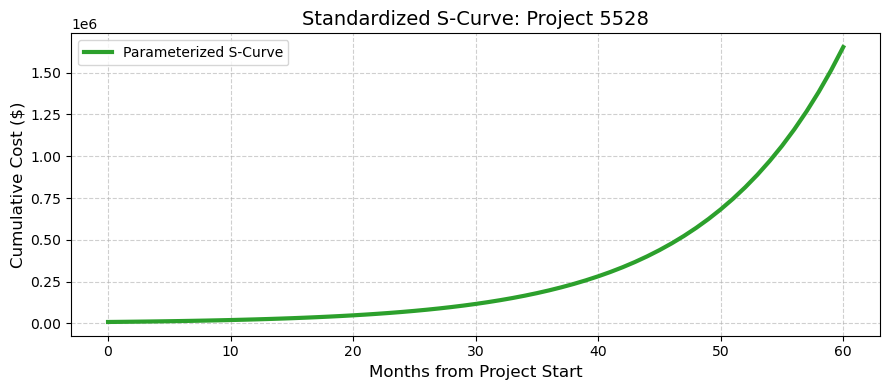

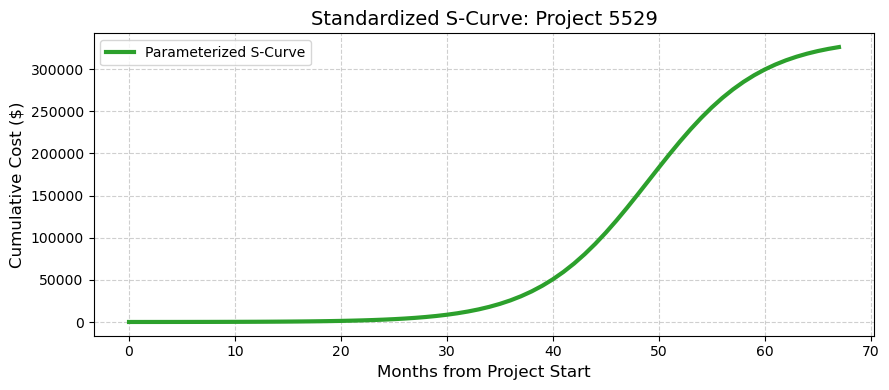

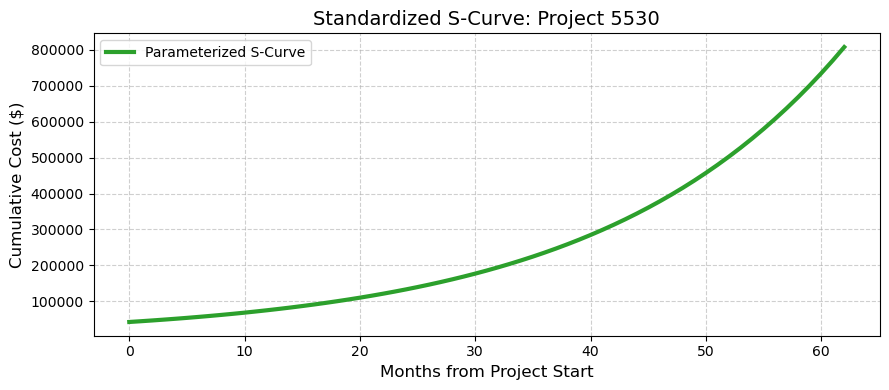

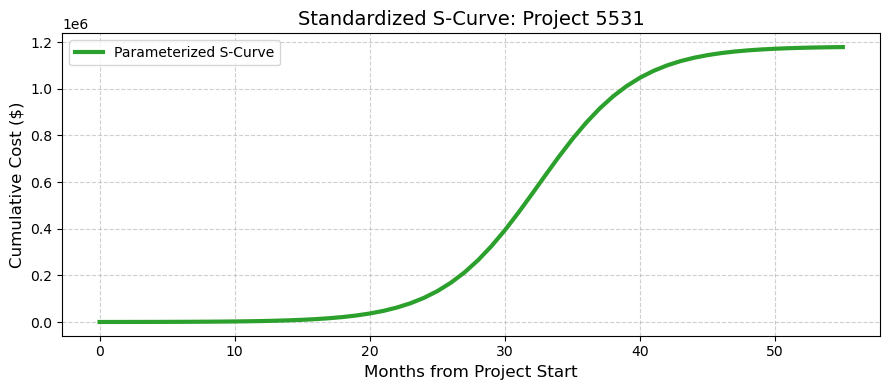

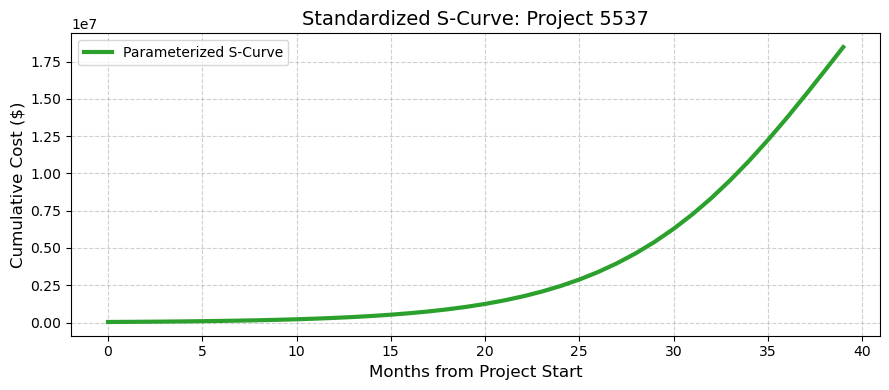

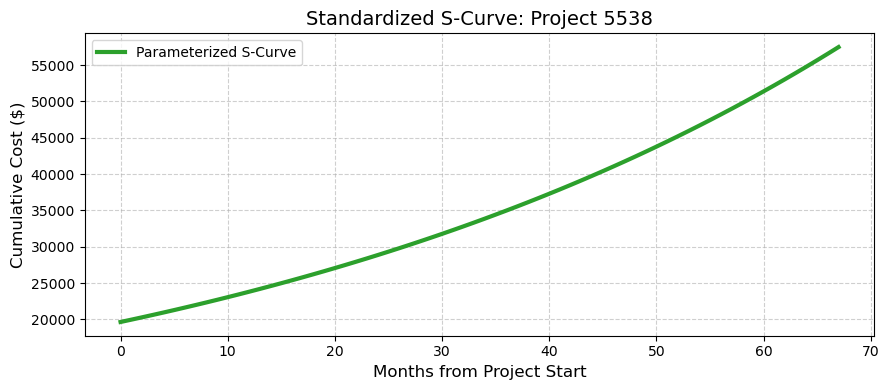

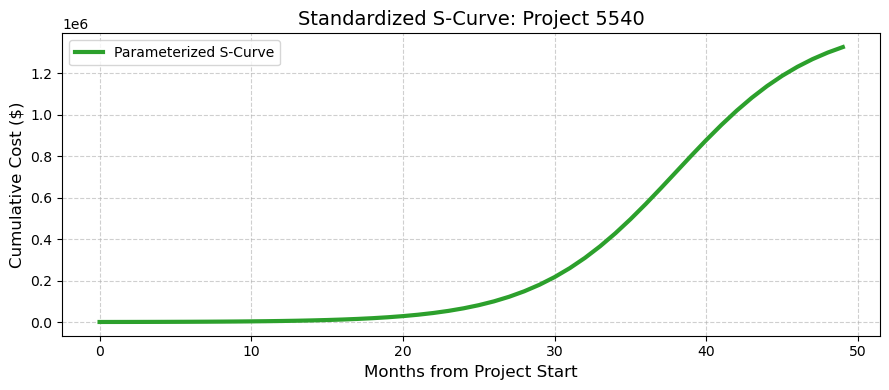

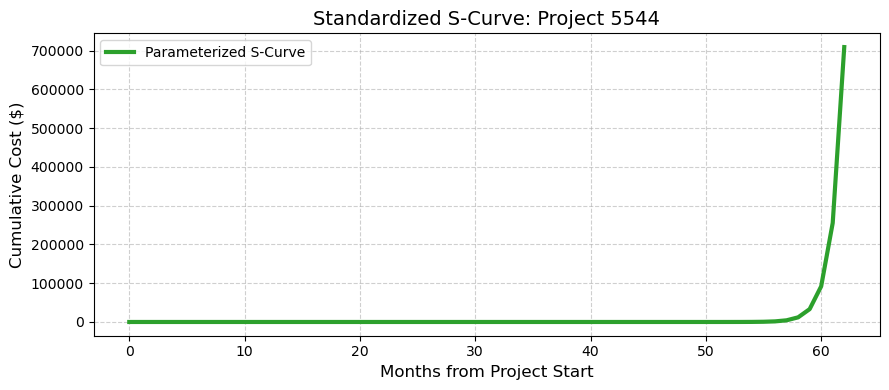

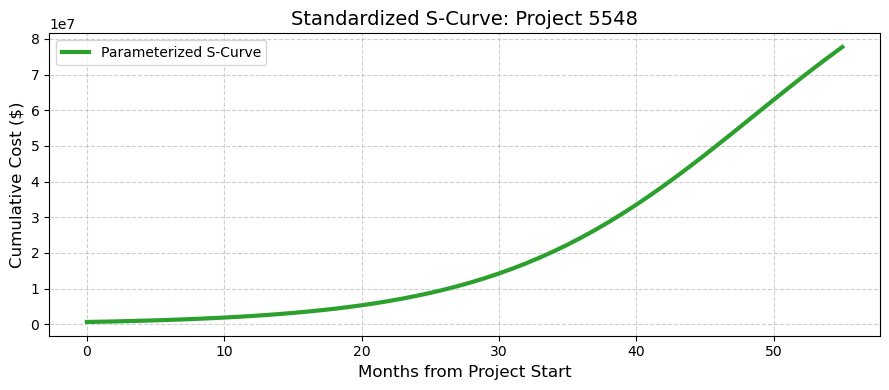

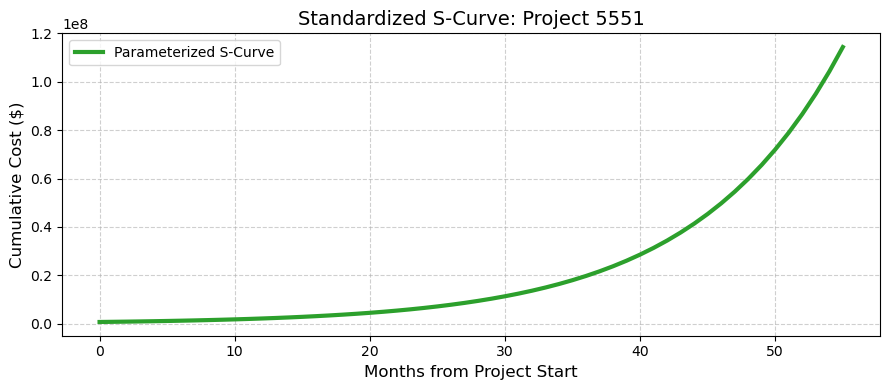

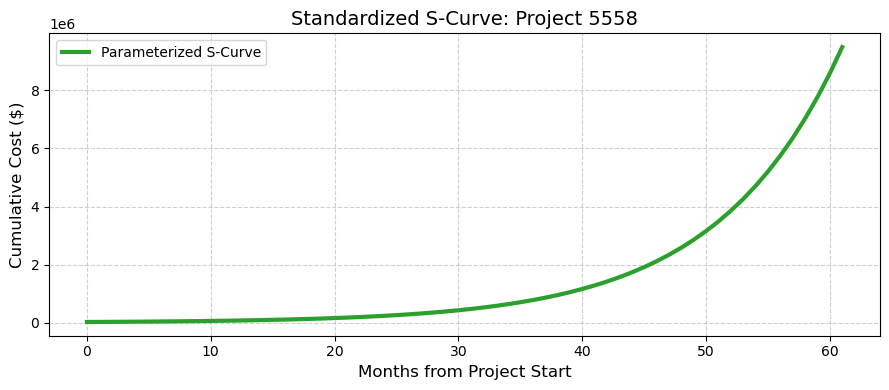

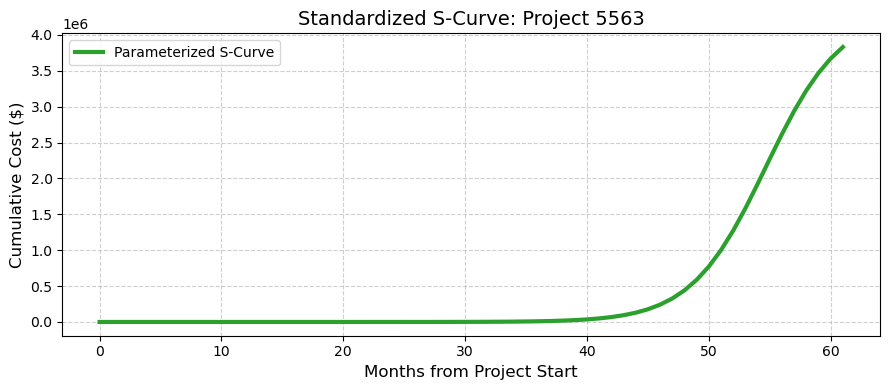

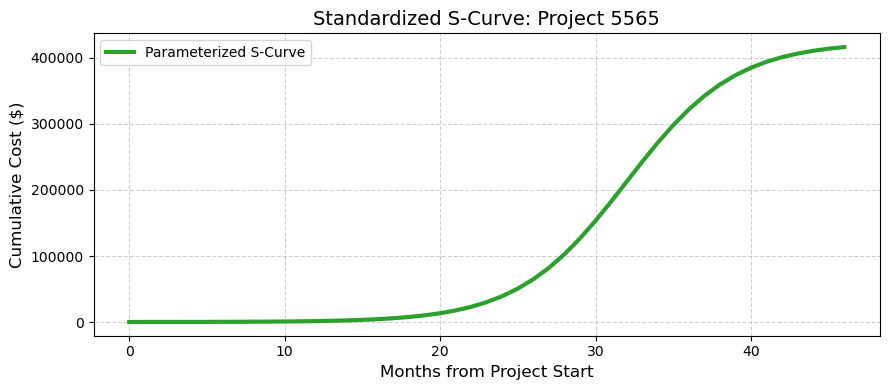

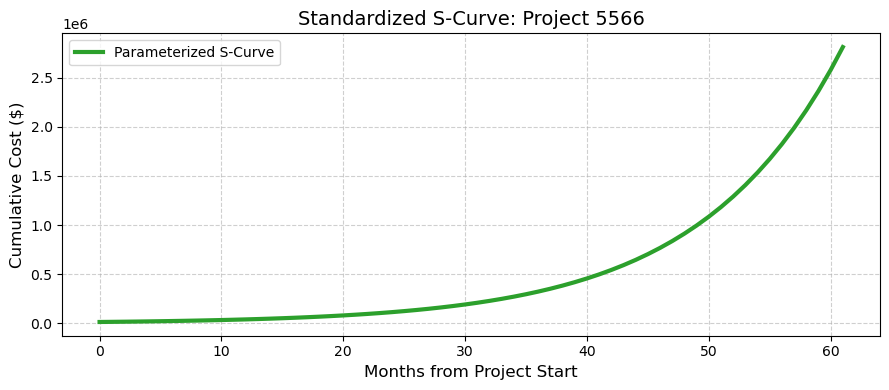

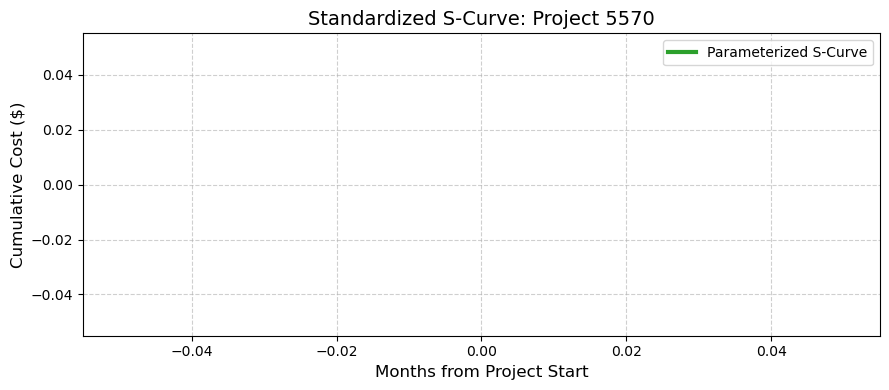

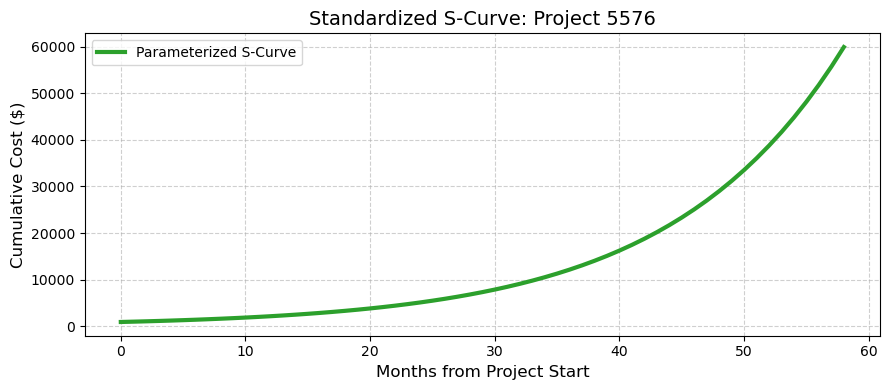

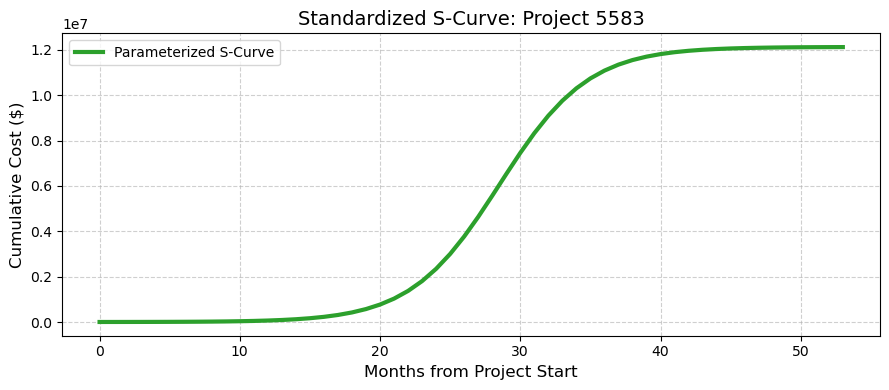

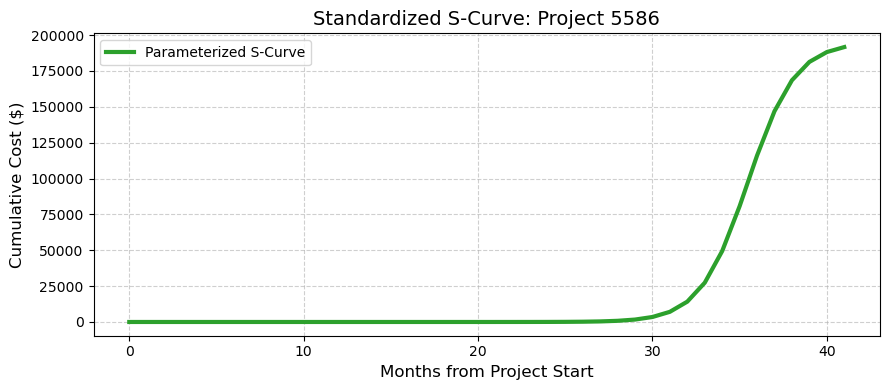

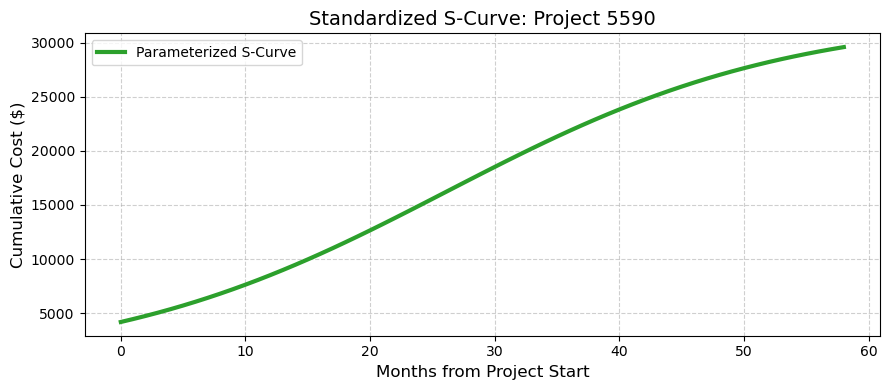

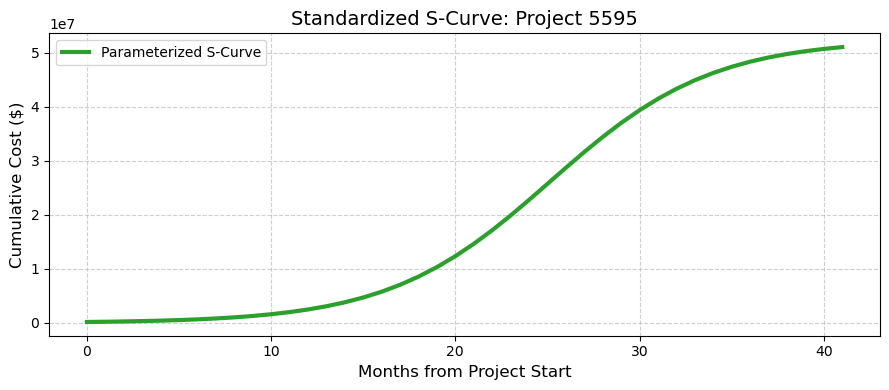

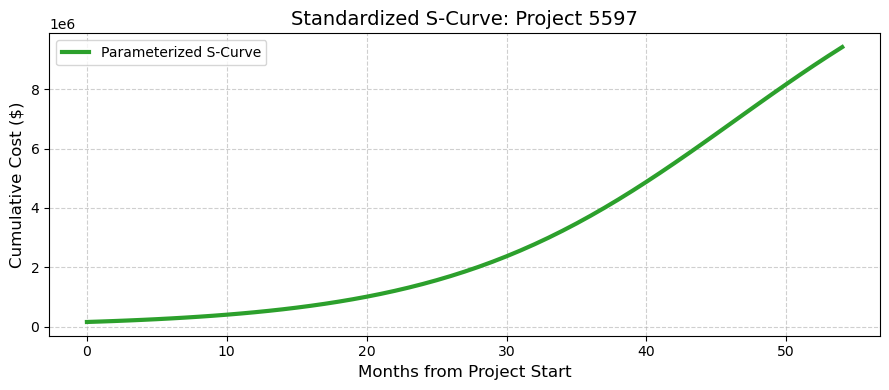

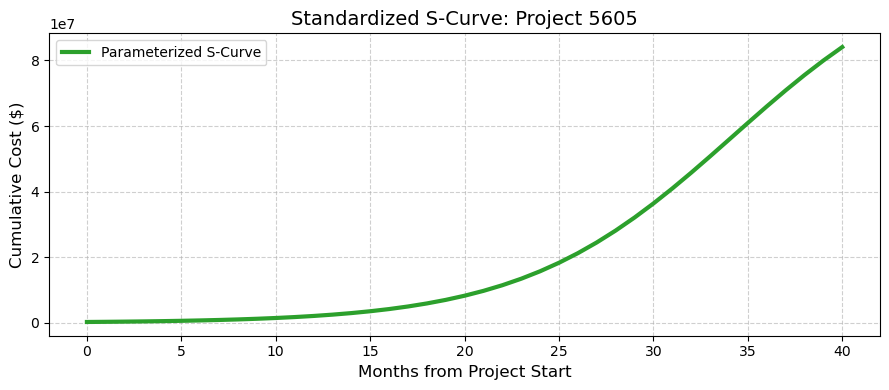

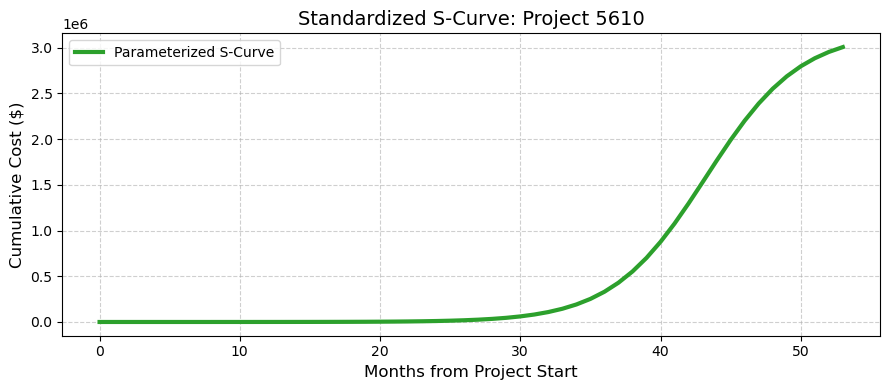

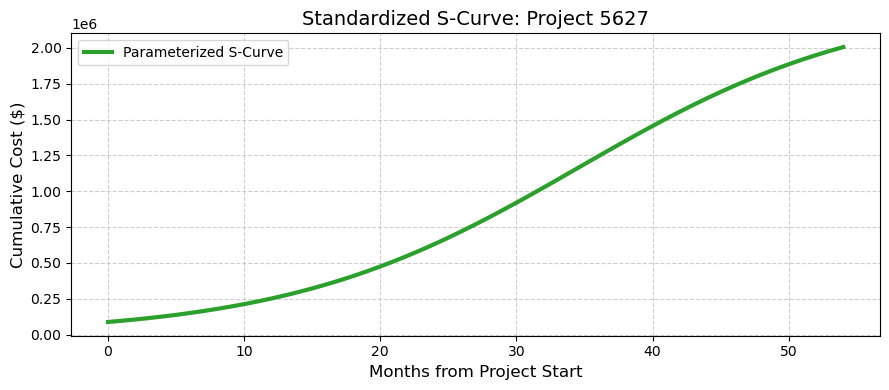

In [13]:
########################################################
"""

Same thing as above but uses a duration variable instead to express length of the project. All 
projects "start" in the same arbitrary place. This is what the model will actually use

"""
########################################################

all_projects_df_2 = all_projects_df.copy()

# Prepare timeline
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

L_params = []
k_params = []
t0_params = []
durations = []

# Loop through the projects
for index, row in all_projects_df_2.iterrows():
    y_data_full = row[timeline_cols].values.astype(float)
    start_idx = np.argmax(y_data_full > 0)
    stop_idx = np.argmax(y_data_full == y_data_full[-1])
        
    # Get duration
    num_months = stop_idx - start_idx + 1
    durations.append(num_months)
        
    # Filter for projects less than 3 months long (if they exist)
    if num_months < 3:
        L_params.append(np.nan)
        k_params.append(np.nan)
        t0_params.append(np.nan)
        continue
            
    y_active = y_data_full[start_idx : stop_idx + 1]
    x_active = np.arange(num_months)
        
    # Fit curves
    initial_guess = [y_active[-1], 0.1, num_months / 2]
    popt, pcov = curve_fit(logistic_curve, x_active, y_active, p0=initial_guess, maxfev=1000000)
    
    L_params.append(popt[0])
    k_params.append(popt[1])
    t0_params.append(popt[2])

# Save all these features as new columns in our dataframe
all_projects_df_2['Duration_Months'] = durations
all_projects_df_2['S_Curve_L'] = L_params
all_projects_df_2['S_Curve_k'] = k_params
all_projects_df_2['S_Curve_t0'] = t0_params

# Check results in table
display(all_projects_df_2[['Project Code', 'Duration_Months', 'S_Curve_L', 'S_Curve_k', 'S_Curve_t0']].head(60))

# Loop through and plot frist 3 projects
for index, row in all_projects_df_2.head(60).iterrows():
    L = row['S_Curve_L']
    k = row['S_Curve_k']
    t0 = row['S_Curve_t0']
    duration = row['Duration_Months']
    
    # Generate X axis
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    
    # Plot the curve
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']}", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12) 
    plt.ylabel("Cumulative Cost ($)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
timeline_dates = pd.date_range(start='2011-01-01', end='2027-06-01', freq='MS')
timeline_cols = timeline_dates.strftime('%b %Y').tolist()

# Replace timeline monthly columns with parameters
all_projects_df = all_projects_df_2.drop(columns=timeline_cols, errors='ignore')

In [15]:
pd.set_option('display.max_rows', None)

# Remove projects 12, 29 and 42 from dataframe (no data - only ~1-2mo in length)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "W5678"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5570"].reset_index(drop=True)
all_projects_df = all_projects_df[all_projects_df["Project Code"].astype(str) != "5454"].reset_index(drop=True)

# Convert 5 features to float
all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']] = all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']].replace({'[\$,]': ''}, regex=True).astype(float)
all_projects_df.head(120)

,Project Code,Projected Budget,Projected Commitments,Estimate at Completion,Duration_Months,S_Curve_L,S_Curve_k,S_Curve_t0
0,4638,4.286000e+07,4.253076e+07,4.286078e+07,129,4.168640e+07,0.186747,107.580958
1,5018,1.500000e+05,8.353324e+04,1.738660e+05,37,6.452617e+04,0.113672,15.090781
2,5046,3.500000e+05,2.677534e+05,3.643228e+05,119,2.668237e+05,0.135722,16.353813
3,5058,5.094500e+08,5.057924e+08,5.095745e+08,67,4.617377e+08,0.197593,38.709869
4,5088,1.850000e+08,1.788290e+08,1.853522e+08,67,1.660232e+08,0.200762,47.672114
5,5105,4.440000e+05,3.362262e+05,4.440000e+05,133,1.509875e+10,0.012344,994.134224
6,5148,4.249000e+08,4.383960e+08,4.265355e+08,120,4.420297e+08,0.139075,98.138398
7,5171,5.702750e+08,5.686872e+08,5.710701e+08,107,5.477962e+08,0.101184,82.457030
8,5198,1.500000e+06,1.286536e+06,1.500000e+06,92,1.247584e+06,0.075928,17.455279
9,5199,5.767000e+06,5.553188e+06,5.767000e+06,95,6.479661e+06,0.060394,56.606855


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

In [ ]:
########################################################
"""

RANDOM FORESTS FOR EACH: Duration, S_Curve_L (Max Value), S_Curve_k (Growth Rate), S_Curve_t0
INTENTION AT THIS STAGE: Compare results and observe potential bottlenecks for model performance

"""
########################################################

In [ ]:
### Duration: ###
print("DURATION IN MONTHS")
print("")

# Define X, Y and train_test_split
X1 = all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
y1 = all_projects_df['Duration_Months']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=99)

# Display ACTUAL labels
print("Actual values for y_test")
print(y1_test.head(20))

# Train and tune Hyperparameters
rf_single1 = RandomForestRegressor(random_state=99)

param_grid1 = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

grid_search1 = GridSearchCV(estimator=rf_single1, param_grid=param_grid1, 
                           cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')

print("Starting hyperparameter tuning...")
grid_search1.fit(X1_train, y1_train)

best_rf_model1 = grid_search1.best_estimator_

print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {grid_search1.best_params_}")
print("")
best_rf_model1.fit(X1_train, y1_train)

# Predict and Evaluate
predictions1 = best_rf_model1.predict(X1_test)
print("Predicted values for y_test")
print(predictions1)

# Calculate the error
mse1 = mean_squared_error(y1_test, predictions1)
rmse1 = np.sqrt(mse1)
print("")
print(f"RMSE for Duration_Months: {rmse1:.4f}")
print("-------------------------------------")

In [ ]:
### S_Curve_L: ###
print("MAX VALUE (S_Curve_L)")
print("")

# Define X, Y and train_test_split
X2 = all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
y2 = all_projects_df['S_Curve_L']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=99)

# Display ACTUAL labels
print("Actual values for y_test")
print(y2_test.head(20))

# Train and tune Hyperparameters
rf_single2 = RandomForestRegressor(random_state=99)

param_grid2 = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

grid_search2 = GridSearchCV(estimator=rf_single2, param_grid=param_grid2, 
                           cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')

print("Starting hyperparameter tuning...")
grid_search2.fit(X2_train, y2_train)

best_rf_model2 = grid_search2.best_estimator_

print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {grid_search2.best_params_}")
print("")
best_rf_model2.fit(X2_train, y2_train)

# Predict and Evaluate
predictions2 = best_rf_model2.predict(X2_test)
print("Predicted values for y_test")
print(predictions2)

# Calculate the error
mse2 = mean_squared_error(y2_test, predictions2)
rmse2 = np.sqrt(mse2)
print("")
print(f"RMSE for Max Value: {rmse2:.4f}")
print("-------------------------------------")

In [ ]:
### S_Curve_k: ###
print("Growth Rate (S_Curve_k)")
print("")

# Define X, Y and train_test_split
X3 = all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
y3 = all_projects_df['S_Curve_k']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=99)

# Display ACTUAL labels
print("Actual values for y_test")
print(y3_test.head(20))

# Train and tune Hyperparameters
rf_single3 = RandomForestRegressor(random_state=99)

param_grid3 = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

grid_search3 = GridSearchCV(estimator=rf_single3, param_grid=param_grid3, 
                           cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')

print("Starting hyperparameter tuning...")
grid_search3.fit(X3_train, y3_train)

best_rf_model3 = grid_search3.best_estimator_

print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {grid_search3.best_params_}")
print("")
best_rf_model3.fit(X3_train, y3_train)

# Predict and Evaluate
predictions3 = best_rf_model3.predict(X3_test)
print("Predicted values for y_test")
print(predictions3)

# Calculate the error
mse3 = mean_squared_error(y3_test, predictions3)
rmse3 = np.sqrt(mse3)
print("")
print(f"RMSE for Growth Rate: {rmse3:.4f}")
print("-------------------------------------")

In [ ]:
### S_Curve_t0: ###
print("Curve Midpoint (S_Curve_t0)")
print("")

# Define X, Y and train_test_split
X4 = all_projects_df[['Projected Budget', 'Projected Commitments', 'Estimate at Completion']]
y4 = all_projects_df['S_Curve_t0']
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=99)

# Display ACTUAL labels
print("Actual values for y_test")
print(y4_test.head(20))

# Train and tune Hyperparameters
rf_single4 = RandomForestRegressor(random_state=99)

param_grid4 = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

grid_search4 = GridSearchCV(estimator=rf_single4, param_grid=param_grid4, 
                           cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')

print("Starting hyperparameter tuning...")
grid_search4.fit(X4_train, y4_train)

best_rf_model4 = grid_search4.best_estimator_

print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {grid_search4.best_params_}")
print("")
best_rf_model4.fit(X4_train, y4_train)

# Predict and Evaluate
predictions4 = best_rf_model4.predict(X4_test)
print("Predicted values for y_test")
print(predictions4)

# Calculate the error
mse4 = mean_squared_error(y4_test, predictions4)
rmse4 = np.sqrt(mse4)
print("")
print(f"RMSE for Curve Midpoint: {rmse4:.4f}")
print("-------------------------------------")

In [ ]:
print(predictions1)
print(predictions2)
print(predictions3)
print(predictions4)

MSE is decent for Growth Rate, but for others... it's still pretty innaccurate. Main bottleneck is I think just lack of data (trained on only 40 examples)

With Random State 99 = predicting on indices: 96, 51, 6, 28, 15, 16, 42, 95, 108, 86, 34, 8, 14, 84, 78, 37, 71, 54, 7, 3
Which are project codes: W5533, 5586, 5148, 5486, 5282, 5301, 5544, W5465, W5717, C4864, 5527, 5198, 5266, C4071, 5728, 5530, 5697, 5597, 5171, 5058


In [ ]:
# 1. Define the list of Project Codes in the exact order they match your predictions
project_codes = [5540, 5659, 5570, 5530, 5566, 5583, 5551, 5456]

# 2. Construct the DataFrame using a dictionary
# We map each column name (the key) to its corresponding array (the value)
predictions_df = pd.DataFrame({
    "Project Code": project_codes,
    "Duration_Months": predictions1,
    "S_Curve_L": predictions2,
    "S_Curve_k": predictions3,
    "S_Curve_t0": predictions4
})

# 3. Inspect the final DataFrame
print("Successfully created Predictions DataFrame:")
display(predictions_df) # Use display() in Jupyter notebooks for a nicely formatted table

In [ ]:
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Define the currency formatter function before the loop
def format_currency(x, pos):
    """Formats large numbers into readable currency (e.g., $1.5M or $500K)"""
    if x >= 1e6:
        return f'${x * 1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x * 1e-3:.0f}K'
    else:
        return f'${x:,.0f}'

# Loop through and plot projects
for index, row in predictions_df.head(60).iterrows():
    L = row['S_Curve_L']
    k = row['S_Curve_k']
    t0 = row['S_Curve_t0']
    duration = row['Duration_Months']
    
    # Generate X axis
    x_data = np.arange(int(duration))
    predicted_y = logistic_curve(x_data, L, k, t0)
    
    # Plot the curve
    plt.figure(figsize=(9, 4))
    plt.plot(x_data, predicted_y, linewidth=3, color='#2ca02c', label="Parameterized S-Curve")
    plt.title(f"Standardized S-Curve: Project {row['Project Code']}", fontsize=14)
    plt.xlabel("Months from Project Start", fontsize=12) 
    plt.ylabel("Cumulative Cost", fontsize=12) # Removed ($) since the formatter adds it
    
    ax = plt.gca() 
    
    # X-Axis: Major ticks every 3 months, minor ticks every 1 month
    ax.xaxis.set_major_locator(MultipleLocator(3))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    
    # Y-Axis: Format as currency, create ~8 even major tick slices
    ax.yaxis.set_major_formatter(FuncFormatter(format_currency))
    ax.yaxis.set_major_locator(plt.MaxNLocator(8)) 
    ax.yaxis.set_minor_locator(plt.MaxNLocator(16)) 
    
    # Update grid to show both major (solid) and minor (dashed) lines
    plt.grid(which='major', color='#CCCCCC', linestyle='-', linewidth=0.8)
    plt.grid(which='minor', color='#EEEEEE', linestyle='--', linewidth=0.5)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

RESULT: Curves are fairly accurate! Duration is not too bad either!

Cumulative cost figures only are wayyy off. (culprit is S_Curve_L)

### NEXT THINGS TO TRY:
- Try a version (make a fresh copy of the book) with only cost data (no sq footage): -> PROS: MORE data, maybe more focused, CONS: less user input (loss of a key feature)

- Use the "Projected Budget" input to replace "Cumulative Cost" (makes sense... this is a better indicator than whatever the model could produce anyway)

- Use models to write a simple script where the user does the inputs (either with gross sq footage or without) and the S-Curve is created